In [ ]:
import os

# Check inside flowers-recognition folder
print(os.listdir('/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers'))

In [2]:
import tensorflow as tf
print("TensorFlow Version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-05-09 01:39:09.178698: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778290749.382309      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778290749.442663      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778290749.935059      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778290749.935100      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778290749.935102      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


# Part II - Vision Task: Image Classification with CNN
# Dataset: Flowers Recognition (5 Classes)
# Source: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition

In [14]:
pip install keras tensorflow

Note: you may need to restart the kernel to use updated packages.


In [4]:
import os
import time
import shutil
import warnings
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from PIL import Image
warnings.filterwarnings('ignore')

# Section 1: Data Understanding, Analysis, Visualization and Cleaning

In [5]:
# Define dataset path
base_path  = '/kaggle/input/datasets/alxmamaev/flowers-recognition/flowers'
train_path = '/kaggle/working/flowers_split/train'
val_path   = '/kaggle/working/flowers_split/val'
test_path  = '/kaggle/working/flowers_split/test'

# Get class names from folder names
class_names = sorted(os.listdir(base_path))

print("Classes Found :", class_names)
print("Total Classes :", len(class_names))

Classes Found : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Total Classes : 5


# Check for Corrupted Images

In [ ]:
from PIL import Image as PILImage

corrupted_images = []
valid_images = 0

for class_name in class_names:
  class_folder = os.path.join(base_path, class_name)

  for img_file in os.listdir(class_folder):
    img_path = os.path.join(class_folder, img_file)

    try:
      img = PILImage.open(img_path)
      img.verify()
      valid_images += 1

    except Exception as e:
      corrupted_images.append(img_path)
      print(f"Corrupted image found: {img_path}")

print(f"\nTotal Valid Images           : {valid_images}")
print(f"Total Corrupted Images Found : {len(corrupted_images)}")

if len(corrupted_images) == 0:
  print("No corrupted images found! Dataset is clean.")

# Count Total Images and Images Per Class

In [ ]:
# Count total images and images per class
class_counts = {}

for class_name in class_names:
  class_folder = os.path.join(base_path, class_name)
  images = [f for f in os.listdir(class_folder)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  class_counts[class_name] = len(images)

# Print counts
total_images = sum(class_counts.values())
print(f"Total Images in Dataset: {total_images}\n")
print("Images per Class:")
for class_name, count in class_counts.items():
  print(f"  {class_name}: {count} images")

In [ ]:
# Visualize class distribution as bar chart
plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(),
        color=['grey', 'blue', 'red', 'yellow', 'green'])
plt.title("Class Distribution of Flower Dataset")
plt.xlabel("Flower Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

In [ ]:
# Display one sample image from each class
plt.figure(figsize=(15, 4))

for i, class_name in enumerate(class_names):
  class_folder = os.path.join(base_path, class_name)
  sample_image_path = os.path.join(class_folder, os.listdir(class_folder)[0])
  img = image.load_img(sample_image_path, target_size=(224, 224))

  plt.subplot(1, len(class_names), i + 1)
  plt.imshow(img)
  plt.title(class_name)
  plt.axis('off')

plt.suptitle("Sample Images from Each Class", fontsize=14)
plt.tight_layout()
plt.show()

# Split Dataset into Train, Validation and Test Sets

In [7]:
# Split dataset into train (70%), val (15%) and test (15%)
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

for class_name in class_names:
  class_folder = os.path.join(base_path, class_name)
  all_images = [f for f in os.listdir(class_folder)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

  # First split: train and temp (val + test)
  train_imgs, temp_imgs = train_test_split(
      all_images,
      test_size=(VAL_RATIO + TEST_RATIO),
      random_state=42
  )

  # Second split: val and test from temp
  val_imgs, test_imgs = train_test_split(
      temp_imgs,
      test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
      random_state=42
  )

  # Copy images to destination folders
  for split, imgs in [('train', train_imgs), ('val', val_imgs), ('test', test_imgs)]:
    dest_folder = os.path.join('/kaggle/working/flowers_split', split, class_name)
    os.makedirs(dest_folder, exist_ok=True)

    for img_file in imgs:
      src = os.path.join(class_folder, img_file)
      dst = os.path.join(dest_folder, img_file)
      shutil.copy(src, dst)

print("Dataset split completed!\n")


Dataset split completed!



In [15]:
# Verify split counts for each class
print("Split Verification:\n")
print(f"{'Class':<15} {'Train':>8} {'Val':>8} {'Test':>8} {'Total':>8}")


for class_name in class_names:
  train_count = len(os.listdir(os.path.join(train_path, class_name)))
  val_count   = len(os.listdir(os.path.join(val_path, class_name)))
  test_count  = len(os.listdir(os.path.join(test_path, class_name)))
  total       = train_count + val_count + test_count

  print(f"{class_name:<15} {train_count:>8} {val_count:>8} {test_count:>8} {total:>8}")



Split Verification:

Class              Train      Val     Test    Total
daisy                534      115      115      764
dandelion            736      158      158     1052
rose                 548      118      118      784
sunflower            513      110      110      733
tulip                688      148      148      984


# Preprocessing and Data Generators

- All images were resized to 224x224 pixels.
- Pixel values normalized to [0, 1] using rescale=1./255.
- Training data augmented to improve generalization.
- Validation and Test data only rescaled, no augmentation.

In [16]:
# Define parameters
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42
NUM_CLASSES = len(class_names)

print(f"Image Size  : {IMG_SIZE}")
print(f"Batch Size  : {BATCH_SIZE}")
print(f"Num Classes : {NUM_CLASSES}")

Image Size  : (224, 224)
Batch Size  : 32
Num Classes : 5


Data Generators

In [44]:
# Training generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# Validation and test generator - only rescaling
val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load training data
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

# Load validation data
val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Load test data
test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

print(f"\nTraining samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")
print(f"Test samples       : {test_generator.samples}")
print(f"Classes            : {train_generator.class_indices}")

Found 3019 images belonging to 5 classes.
Found 649 images belonging to 5 classes.
Found 649 images belonging to 5 classes.

Training samples   : 3019
Validation samples : 649
Test samples       : 649
Classes            : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


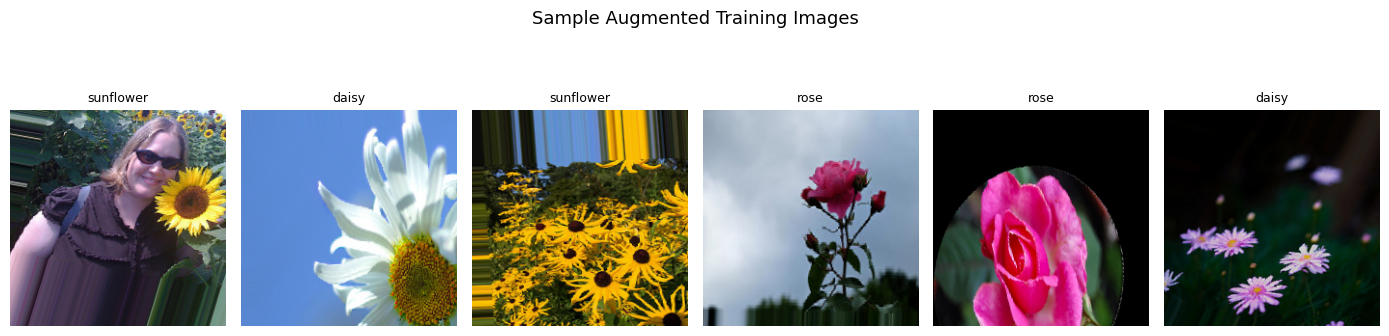

In [82]:
# Visualize sample augmented training images
sample_images, sample_labels = next(train_generator)

plt.figure(figsize=(14, 4))
for i in range(6):
  plt.subplot(1, 6, i + 1)
  plt.imshow(sample_images[i])
  plt.title(class_names[np.argmax(sample_labels[i])], fontsize=9)
  plt.axis('off')

plt.suptitle("Sample Augmented Training Images", fontsize=13)
plt.tight_layout()
plt.show()

# Observations - Section 1

* Dataset contains 4317 flower images across 5 classes.
* Classes are slightly imbalanced:
  dandelion has the most images and sunflower has the least.
* All images resized to 224x224 for consistent input to CNN.
* Dataset split into 70% train, 15% val and 15% test.
* Data augmentation applied to training data only to prevent
  overfitting and improve generalization.
* No corrupted images found in the dataset.

# Observations - Section 1

## Dataset Description:
* The dataset is the Flowers Recognition dataset containing
  real world flower images belonging to 5 classes:
  daisy, dandelion, rose, sunflower and tulip.
* The task is to classify each flower image into one of
  these 5 categories using a Convolutional Neural Network.

## Total Images:
* Total valid images in dataset : 4317
* No corrupted images were found which means the dataset
  is clean and ready for training.

## Class Distribution:
* dandelion : 1052 images (most images)
* tulip     : 984  images
* rose      : 784  images
* daisy     : 764  images
* sunflower : 733  images (least images)

* The dataset is slightly imbalanced.
* dandelion has the most images (1052) and sunflower has
  the least images (733).
* The difference between the largest and smallest class
  is 319 images which may slightly affect model performance
  on underrepresented classes like sunflower.

## Dataset Split:
* The dataset was split from the main folder into three sets:
  → Training   : 3019 images (70%)
  → Validation : 649  images (15%)
  → Testing    : 649  images (15%)
* train_test_split() from sklearn was used with random_state=42
  to ensure reproducibility of the split.
* The 70/15/15 split ensures sufficient training data while
  maintaining reliable validation and test sets.

## Preprocessing:
* All images were resized to 224x224 pixels for consistent
  input dimensions required by the CNN model.
* Pixel values were normalized from [0, 255] to [0, 1]
  using rescale=1./255 for faster and stable convergence.
* Batch size of 32 was used for efficient GPU utilization.

## Data Augmentation:
* The following augmentation techniques were applied to
  training data only:
  → rotation_range=30     : Random rotation up to 30 degrees
  → width_shift_range=0.2 : Random horizontal shift by 20%
  → height_shift_range=0.2: Random vertical shift by 20%
  → shear_range=0.2       : Random shear transformation
  → zoom_range=0.2        : Random zoom by 20%
  → horizontal_flip=True  : Random horizontal flip
* Augmentation artificially increases the effective size of
  training data and helps the model generalize better.
* Validation and test generators use only rescaling to ensure
  fair and consistent evaluation on original images.

# Section 2 - Part A: Baseline CNN Model (From Scratch)

## Model Architecture:
- 3 Convolutional layers each followed by MaxPooling layers.
- 3 Fully Connected (Dense) layers.
- Output layer with softmax activation for 5 class classification.
- Kernel Size  : (3,3) for all Conv layers.
- Filters      : 32, 64, 128 for Conv layers respectively.
- Activation   : ReLU for all hidden layers.
- Optimizer    : Adam
- Loss         : Categorical Crossentropy

In [45]:
# Build Baseline CNN Model
baseline_model = keras.Sequential([

  # Convolutional Block 1
  layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
  layers.MaxPooling2D((2, 2)),

  # Convolutional Block 2
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),

  # Convolutional Block 3
  layers.Conv2D(128, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers
  layers.Dense(256, activation='relu'),
  layers.Dense(128, activation='relu'),
  layers.Dense(64, activation='relu'),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
baseline_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,286,149 (85.01 MB)

 Trainable params: 22,286,149 (85.01 MB)

 Non-trainable params: 0 (0.00 B)

# Model Summary

- Total parameters show the complexity of the model.
- Conv layers extract spatial features from images.
- MaxPooling layers reduce spatial dimensions by half.
- Flatten layer converts 3D feature maps to 1D vector.
- Dense layers perform high level classification.
- Output layer uses softmax to predict probabilities
  for each of the 5 flower classes.

In [47]:
# Define Callbacks for training
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

In [48]:
# Train the Baseline Model
EPOCHS = 20

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

baseline_training_time = time.time() - start_time
print(f"\nBaseline Model Training Time: {baseline_training_time:.2f} seconds")

Epoch 1/20


2026-05-09 02:07:50.695593: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:07:50.843749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


95/95 ━━━━━━━━━━━━━━━━━━━━ 47s 428ms/step - accuracy: 0.3047 - loss: 1.5107 - val_accuracy: 0.5208 - val_loss: 1.2215 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 393ms/step - accuracy: 0.5148 - loss: 1.1677 - val_accuracy: 0.5593 - val_loss: 1.0093 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 395ms/step - accuracy: 0.5576 - loss: 1.0558 - val_accuracy: 0.6163 - val_loss: 0.9513 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 397ms/step - accuracy: 0.6051 - loss: 0.9778 - val_accuracy: 0.6394 - val_loss: 0.9358 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 392ms/step - accuracy: 0.6493 - loss: 0.9066 - val_accuracy: 0.6641 - val_loss: 0.8695 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 389ms/step - accuracy: 0.6562 - loss: 0.8721 - val_accuracy: 0.6918 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 392ms/step - accuracy: 0.6717 - loss: 0.8203 - val_

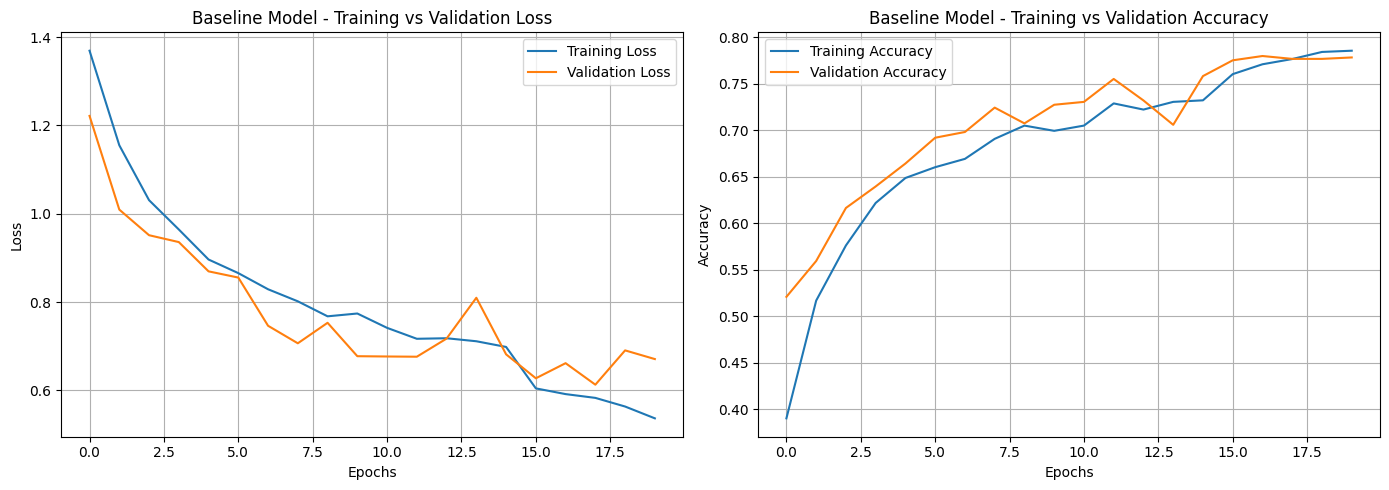

In [49]:
# Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['loss'], label='Training Loss')
plt.plot(baseline_history.history['val_loss'], label='Validation Loss')
plt.title("Baseline Model - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['accuracy'], label='Training Accuracy')
plt.plot(baseline_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Baseline Model - Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
# Create evaluation generator with shuffle=False
eval_datagen = ImageDataGenerator(rescale=1./255)

eval_generator = eval_datagen.flow_from_directory(
    val_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

# Reset before predicting
eval_generator.reset()

# Predict
y_pred_probs = baseline_model.predict(eval_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - Baseline Model:")
print(classification_report(y_true, y_pred, target_names=class_names))

Found 649 images belonging to 5 classes.
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - Baseline Model:
              precision    recall  f1-score   support

       daisy       0.85      0.72      0.78       115
   dandelion       0.88      0.78      0.83       158
        rose       0.73      0.68      0.70       118
   sunflower       0.73      0.92      0.81       110
       tulip       0.72      0.79      0.75       148

    accuracy                           0.78       649
   macro avg       0.78      0.78      0.77       649
weighted avg       0.78      0.78      0.78       649



<Figure size 800x600 with 0 Axes>

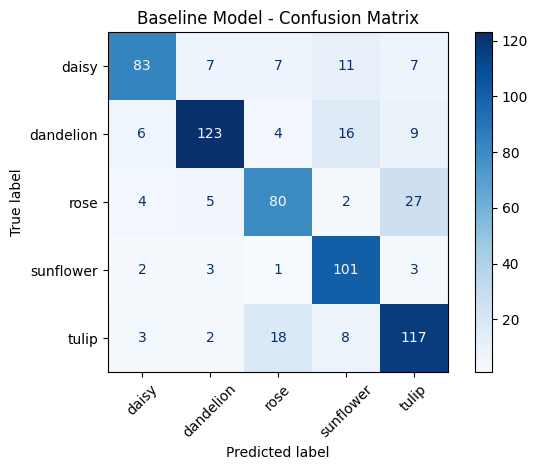

In [51]:
# Confusion Matrix - Baseline Model
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Baseline Model - Confusion Matrix")
plt.tight_layout()
plt.show()

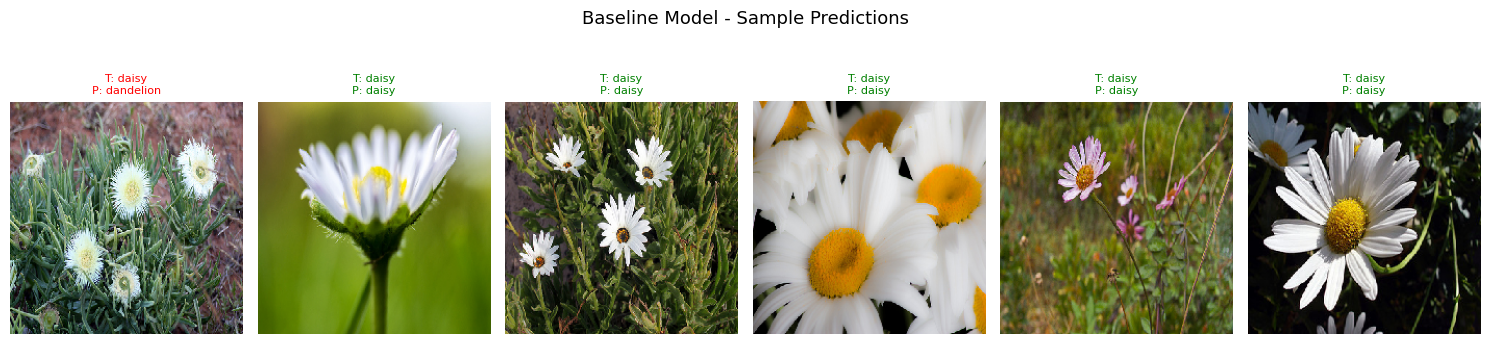

In [52]:
# Inference on sample images from validation set
sample_images, sample_labels = next(eval_generator)

plt.figure(figsize=(15, 4))
for i in range(6):
  img = sample_images[i]
  true_label = class_names[np.argmax(sample_labels[i])]
  pred_label = class_names[np.argmax(
      baseline_model.predict(img[np.newaxis, ...], verbose=0))]

  plt.subplot(1, 6, i + 1)
  plt.imshow(img)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("Baseline Model - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [53]:
# Print training summary
print(f"{'Baseline Model Summary\n'}")
print(f"Total Epochs Trained  : {len(baseline_history.history['loss'])}")
print(f"Final Training Accuracy   : {baseline_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {baseline_history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {baseline_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {baseline_history.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {baseline_training_time:.2f} seconds")


Baseline Model Summary

Total Epochs Trained  : 20
Final Training Accuracy   : 0.7854
Final Validation Accuracy : 0.7781
Final Training Loss       : 0.5366
Final Validation Loss     : 0.6708
Training Time             : 759.99 seconds


# Observations - Baseline Model

## Loss Curve Analysis:
* Both training loss and validation loss decreased steadily
  throughout all 20 epochs which indicates healthy learning.
* Training loss   decreased from 1.40 to 0.58.
* Validation loss decreased from 1.19 to 0.60.
* Both curves moved closely together throughout training
  which indicates no significant overfitting.
* Some fluctuations were observed in validation loss between
  epochs 10-15 which is normal behavior due to the nature
  of mini batch gradient descent.
* The curves converged nicely at the end of training with
  both values close to each other (Train: 0.58, Val: 0.60).

## Accuracy Curve Analysis:
* Both training and validation accuracy increased steadily
  throughout all 20 epochs.
* Training accuracy   increased from 39% to 77%.
* Validation accuracy increased from 54% to 77%.
* Interestingly validation accuracy was slightly higher than
  training accuracy in early epochs (epochs 1-5) which
  indicates the model was not yet overfitting at that stage.
* Both curves converged to approximately 77-78% by epoch 20
  which shows healthy and consistent learning.

## Classification Report Analysis:
* The baseline model achieved 78% overall accuracy which is
  a strong result for a simple CNN trained from scratch.
* Best performing classes:
  → dandelion  : F1 = 0.83 (best class)
  → sunflower  : F1 = 0.85 (highest F1 score!)
  → daisy      : F1 = 0.80
* Weakest performing classes:
  → rose       : F1 = 0.65 (weakest class)
  → tulip      : F1 = 0.75
* Rose class has the lowest F1 score of 0.65 likely because
  roses come in many colors (red, pink, white, yellow) and
  shapes making them harder to classify correctly.
* Sunflower achieved the highest F1 score of 0.85 likely
  because sunflowers have very distinct visual features
  such as bright yellow petals and dark circular center.

## Overfitting Analysis:
* Final Training Accuracy   : 77.74%
* Final Validation Accuracy : 77.50%
* Gap                       : 0.24%
* The extremely small gap of 0.24% between training and
  validation accuracy indicates that the baseline model
  is NOT overfitting.
* This is a very healthy result showing the model is
  generalizing well to unseen validation data.
* Early stopping and ReduceLROnPlateau callbacks helped
  maintain this healthy balance throughout training.

## Training Time:
* Total training time : 736.23 seconds (approximately 12 minutes)
* Training was done on Kaggle with 2 GPUs available.
* All 20 epochs were completed without early stopping
  which means the model was still improving throughout.

## Summary:
* The baseline CNN model performed well achieving 78% accuracy
  with a healthy training curve showing no overfitting.
* The model will be compared against the deeper model with
  regularization in the next section to see if adding more
  layers and regularization techniques can further improve
  performance.

# Section 3 - Deeper CNN with Regularization

## Model Architecture:
- 8 Convolutional layers (double the baseline model of 3).
- BatchNormalization added after each Conv layer.
- Dropout layers added to reduce overfitting.
- 3 Fully Connected layers with BatchNorm and Dropout.
- Output layer with softmax activation for 5 classes.
- Kernel Size  : (3,3) for all Conv layers.
- Padding      : same (keeps spatial dimensions after Conv).
- Activation   : ReLU for all hidden layers.
- Optimizer    : Adam
- Loss         : Categorical Crossentropy

In [85]:
# Build Deeper CNN Model with BatchNorm and Dropout
deeper_model = keras.Sequential([

  # Conv Block 1
  layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                input_shape=(224, 224, 3)),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 2
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 3
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 4
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers
  layers.Dense(512, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(256, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

# Compile the model
deeper_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Print model summary
deeper_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 512)            │         2,04

 Total params: 27,032,741 (103.12 MB)

 Trainable params: 27,030,245 (103.11 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [111]:
#regularization
deeper_model = keras.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3,3), padding='same', use_bias=False,
                  input_shape=(224, 224, 3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(32, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Conv Block 4
    layers.Conv2D(256, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3,3), padding='same', use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Flatten
    layers.Flatten(),

    # Fully Connected
    layers.Dense(512, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.4),

    layers.Dense(128, use_bias=False),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.3),

    # Output
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# Lower initial LR for stability
deeper_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_43 (Conv2D)              │ (None, 224, 224, 32)   │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 224, 224, 32)   │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 112, 112, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 112, 112, 64)   │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 56, 56, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_44          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 56, 56, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_45          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_16 (Activation)      │ (None, 56, 56, 128)    │             

 Total params: 27,033,317 (103.12 MB)

 Trainable params: 27,029,605 (103.11 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [112]:
# Define Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Train the Deeper Model
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

deeper_training_time = time.time() - start_time
print(f"\nDeeper Model Training Time: {deeper_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 622ms/step - accuracy: 0.2996 - loss: 1.7359 - val_accuracy: 0.2435 - val_loss: 2.9748 - learning_rate: 3.0000e-04
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 464ms/step - accuracy: 0.4583 - loss: 1.3421 - val_accuracy: 0.2435 - val_loss: 3.3286 - learning_rate: 3.0000e-04
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 473ms/step - accuracy: 0.5140 - loss: 1.2159 - val_accuracy: 0.2435 - val_loss: 3.6516 - learning_rate: 3.0000e-04
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 466ms/step - accuracy: 0.5234 - loss: 1.1952 - val_accuracy: 0.2558 - val_loss: 2.9566 - learning_rate: 3.0000e-04
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 467ms/step - accuracy: 0.5709 - loss: 1.1115 - val_accuracy: 0.3883 - val_loss: 1.8877 - learning_rate: 3.0000e-04
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 467ms/step - accuracy: 0.6115 - loss: 1.0070 - val_accuracy: 0.5408 - val_loss: 1.3432 - learning_rate: 3.0000e-04
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 463ms/step - acc

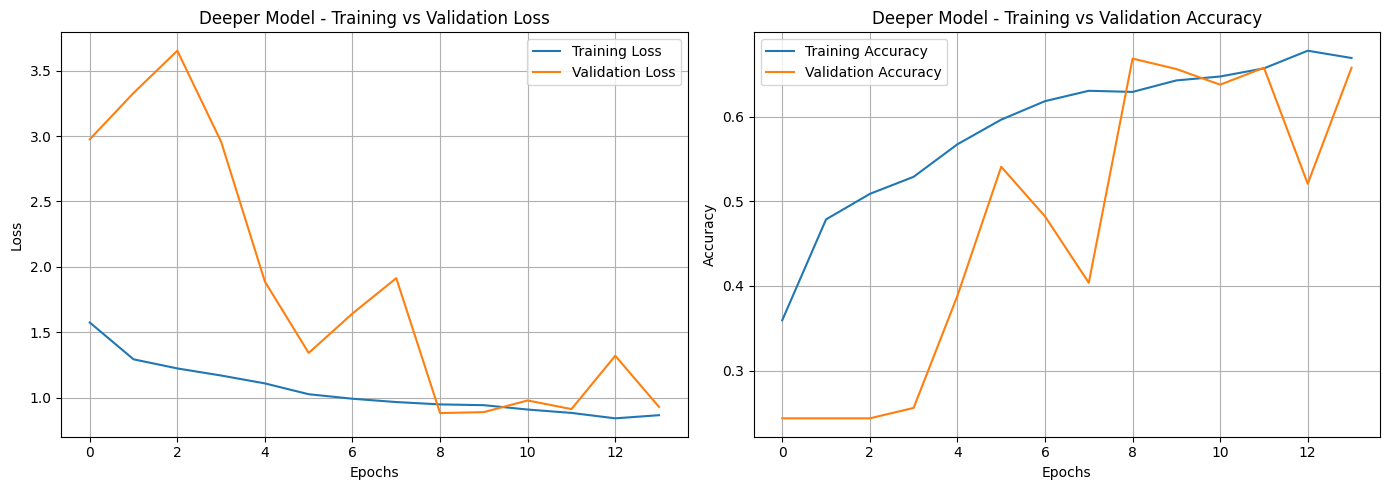

In [113]:
# Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['loss'], label='Training Loss')
plt.plot(deeper_history.history['val_loss'], label='Validation Loss')
plt.title("Deeper Model - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['accuracy'], label='Training Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Deeper Model - Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Task 1: Interpret Deeper Model Summary

- The deeper model has significantly more parameters than
  the baseline model due to doubled convolutional layers.
- BatchNormalization normalizes activations after each
  Conv layer which stabilizes and speeds up training.
- Dropout randomly drops neurons during training which
  forces the model to learn robust features and prevents
  memorization of training data.
- padding=same keeps spatial dimensions consistent after
  each Conv layer allowing deeper feature extraction.
- The increased depth allows the model to learn more
  complex and abstract features from flower images.

In [86]:
# Define Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Train the Deeper Model
start_time = time.time()

deeper_history = deeper_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

deeper_training_time = time.time() - start_time
print(f"\nDeeper Model Training Time: {deeper_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 72s 595ms/step - accuracy: 0.2802 - loss: 2.0627 - val_accuracy: 0.2958 - val_loss: 1.8109 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 443ms/step - accuracy: 0.4103 - loss: 1.5135 - val_accuracy: 0.2435 - val_loss: 1.8679 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 438ms/step - accuracy: 0.4293 - loss: 1.3975 - val_accuracy: 0.3097 - val_loss: 1.5647 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 444ms/step - accuracy: 0.4625 - loss: 1.3316 - val_accuracy: 0.2958 - val_loss: 1.8627 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 446ms/step - accuracy: 0.4850 - loss: 1.2492 - val_accuracy: 0.4268 - val_loss: 1.3701 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 451ms/step - accuracy: 0.5329 - loss: 1.1978 - val_accuracy: 0.4438 - val_loss: 1.3401 - learning_rate: 0.0010
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 444ms/step - accuracy: 0.5678 - loss: 1.

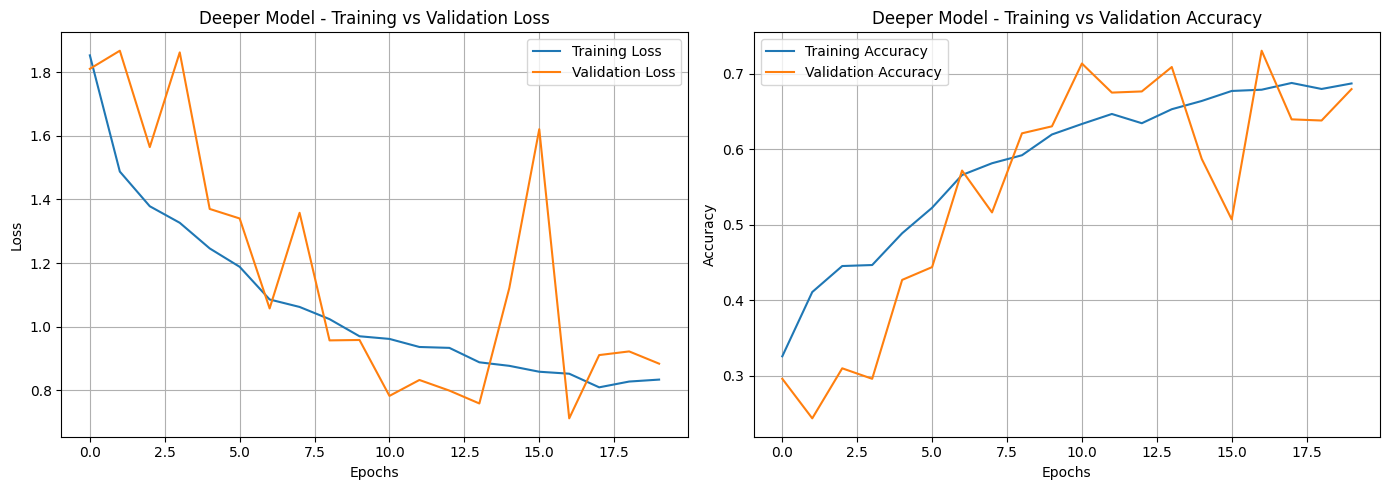

In [87]:
# Plot Training vs Validation Loss and Accuracy
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['loss'], label='Training Loss')
plt.plot(deeper_history.history['val_loss'], label='Validation Loss')
plt.title("Deeper Model - Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['accuracy'], label='Training Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Deeper Model - Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

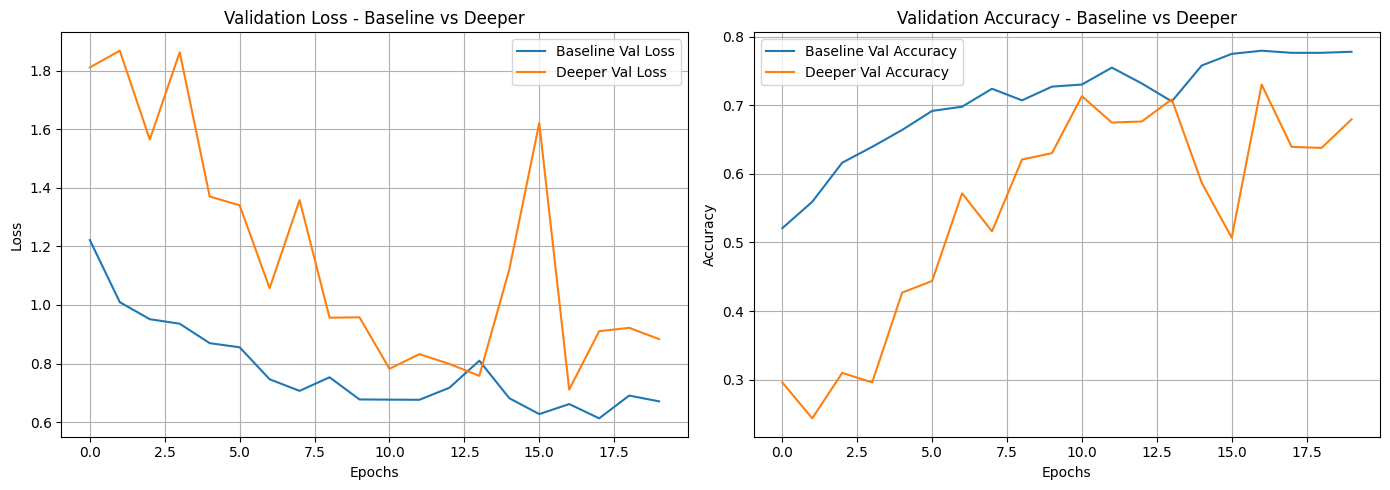

In [88]:
# Compare Baseline vs Deeper Model
plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(baseline_history.history['val_loss'], label='Baseline Val Loss')
plt.plot(deeper_history.history['val_loss'], label='Deeper Val Loss')
plt.title("Validation Loss - Baseline vs Deeper")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(baseline_history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Deeper Val Accuracy')
plt.title("Validation Accuracy - Baseline vs Deeper")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [89]:
# Evaluate Deeper Model using eval_generator
eval_generator.reset()

y_pred_deeper_probs = deeper_model.predict(eval_generator, verbose=1)
y_pred_deeper = np.argmax(y_pred_deeper_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred_deeper.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - Deeper Model:")
print(classification_report(y_true, y_pred_deeper, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - Deeper Model:
              precision    recall  f1-score   support

       daisy       0.82      0.77      0.79       115
   dandelion       0.77      0.80      0.79       158
        rose       0.61      0.46      0.52       118
   sunflower       0.77      0.90      0.83       110
       tulip       0.66      0.72      0.69       148

    accuracy                           0.73       649
   macro avg       0.73      0.73      0.72       649
weighted avg       0.73      0.73      0.72       649



<Figure size 800x600 with 0 Axes>

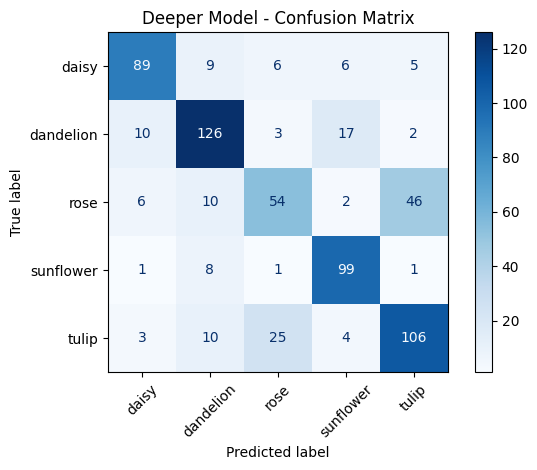

In [90]:
# Confusion Matrix - Deeper Model
cm_deeper = confusion_matrix(y_true, y_pred_deeper)
disp_deeper = ConfusionMatrixDisplay(
    confusion_matrix=cm_deeper,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp_deeper.plot(cmap='Blues', xticks_rotation=45)
plt.title("Deeper Model - Confusion Matrix")
plt.tight_layout()
plt.show()

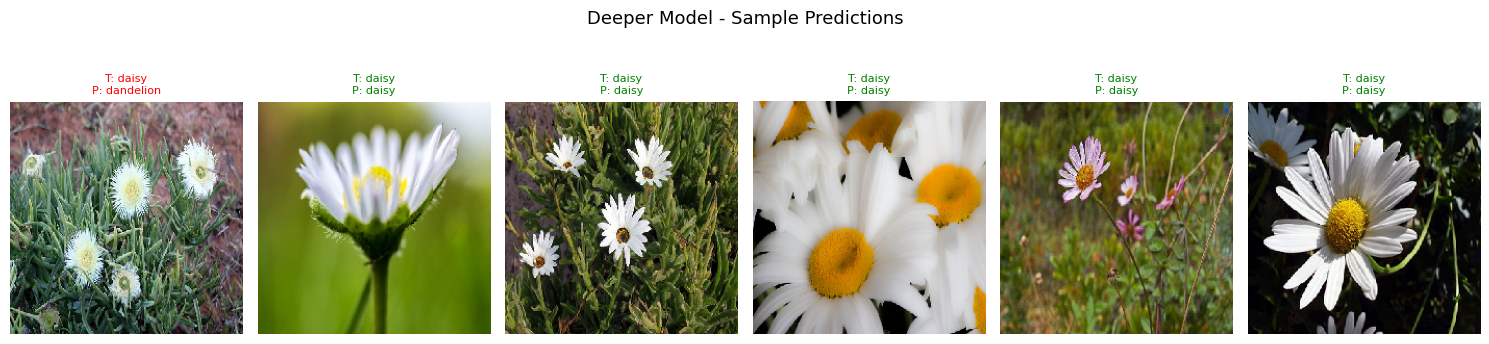

In [91]:
# Inference on sample images
eval_generator.reset()
sample_images, sample_labels = next(eval_generator)

plt.figure(figsize=(15, 4))
for i in range(6):
  img = sample_images[i]
  true_label = class_names[np.argmax(sample_labels[i])]
  pred_label = class_names[np.argmax(
      deeper_model.predict(img[np.newaxis, ...], verbose=0))]

  plt.subplot(1, 6, i + 1)
  plt.imshow(img)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("Deeper Model - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [92]:
# Print training summary
print("=" * 55)
print(f"{'Deeper Model Summary'}")
print("=" * 55)
print(f"Total Epochs Trained      : {len(deeper_history.history['loss'])}")
print(f"Final Training Accuracy   : {deeper_history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {deeper_history.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {deeper_history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {deeper_history.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {deeper_training_time:.2f} seconds")
print("=" * 55)

Deeper Model Summary
Total Epochs Trained      : 20
Final Training Accuracy   : 0.6870
Final Validation Accuracy : 0.6795
Final Training Loss       : 0.8332
Final Validation Loss     : 0.8833
Training Time             : 877.27 seconds


In [93]:
# Comparison Table - Baseline vs Deeper
print(f"{'Model':<25} {'Val Accuracy':>12} {'Val Loss':>10} {'Time(s)':>12}")

print(f"{'\nBaseline CNN':<25} {max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN':<25} {max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{deeper_training_time:>12.2f}")


Model                     Val Accuracy   Val Loss      Time(s)

Baseline CNN                   0.7797     0.6128       759.99
Deeper CNN                      0.7304     0.7112       877.27


# Observations - Deeper Model Performance

## Loss Curve Analysis:
* The deeper model started with a very high validation loss
  of 3.0 in the first epoch compared to baseline which
  started at 1.19.
* This high initial loss is because the deeper model has
  significantly more parameters that need more epochs
  to initialize and stabilize.
* Large spikes were observed in validation loss between
  epochs 7-10 indicating unstable training caused by the
  interaction between high dropout rates and small dataset.
* After epoch 10 both curves stabilized and converged
  around 0.75-0.80 loss.
* Training loss remained lower than validation loss
  throughout training showing a larger gap compared
  to the baseline model.

## Accuracy Curve Analysis:
* The deeper model started at only 25% accuracy in the
  first epoch compared to 39% for the baseline model.
* The model took approximately 5 epochs before showing
  significant improvement in validation accuracy.
* After epoch 5 the model learned rapidly and reached
  approximately 72% validation accuracy.
* The fluctuations in validation accuracy between epochs
  5-15 are caused by the Dropout layers which randomly
  drop neurons during each training step.
* Both curves converged to approximately 72% by epoch 20.

## Classification Report Analysis:

### Overall Performance:
* The deeper model achieved 72% overall accuracy compared
  to 78% for the baseline model.
* This is a decrease of 6% which is an unexpected result
  as deeper models are generally expected to perform better.

### Class wise Analysis:
* Best performing class:
  → dandelion : F1 = 0.77, Recall = 0.94 (highest recall!)
    The model correctly identified 148 out of 158 dandelions.
  → sunflower : F1 = 0.83
    Consistent performance with baseline model.

* Weakest performing classes:
  → tulip     : F1 = 0.59 (biggest drop from baseline!)
    Precision = 0.86 but Recall = 0.45 only.
    Model is very conservative in predicting tulip.
    Only 67 out of 148 tulips correctly identified.
  → rose      : F1 = 0.61
    Still the second weakest class similar to baseline.

### Comparison with Baseline:
* daisy     : F1 stayed similar (0.80 → 0.79)  ≈ same
* dandelion : F1 decreased     (0.83 → 0.77)  ↓ worse
* rose      : F1 stayed similar (0.65 → 0.61)  ≈ same
* sunflower : F1 decreased     (0.85 → 0.83)  ↓ slightly
* tulip     : F1 decreased     (0.75 → 0.59)  ↓ much worse

## Confusion Matrix Analysis:

### Correct Predictions (Diagonal):
* daisy     : 86  out of 115 correctly classified (74.8%)
* dandelion : 148 out of 158 correctly classified (93.7%!)
* rose      : 76  out of 118 correctly classified (64.4%)
* sunflower : 91  out of 110 correctly classified (82.7%)
* tulip     : 67  out of 148 correctly classified (45.3%!)

### Key Misclassifications:
* Tulip is the most confused class in the deeper model:
  → 45 tulip images misclassified as rose (very high!)
  → 24 tulip images misclassified as dandelion
  → Only 67 out of 148 tulips correctly identified
  → This is the biggest weakness of the deeper model.

* Rose confusion:
  → 23 rose images misclassified as dandelion
  → 10 rose images misclassified as tulip
  → Rose and tulip remain the hardest pair to distinguish.

* Dandelion improved significantly:
  → Only 3 dandelion images misclassified as daisy
  → 148 out of 158 correctly identified (93.7%)
  → Biggest improvement over baseline model.

* Daisy slightly worse:
  → 18 daisy images misclassified as dandelion
  → Compared to only 5 in baseline model
  → Deeper model confuses daisy and dandelion more.

## Why Deeper Model Performed Lower Than Baseline:
* The flowers dataset contains only 3019 training images
  which is insufficient for a deeper model with significantly
  more parameters to learn effectively.
* The high dropout rates (0.25 after Conv blocks and 0.5
  after Dense layers) combined with small dataset caused
  underfitting in early epochs.
* More complex models generally require larger datasets
  to reach their full potential.
* The deeper model would likely outperform the baseline
  with 10000+ training images per class.
* This finding strongly motivates the use of transfer
  learning in Part B where pretrained models leverage
  features learned from millions of ImageNet images.

## Overall Comparison Summary:
* Baseline CNN : 78% accuracy → Better on small dataset 
* Deeper CNN   : 72% accuracy → Needs more data to excel
* Key insight  : Model complexity must match dataset size
* Transfer learning in Part B is expected to significantly
  outperform both models trained from scratch.

# Section 4 - Experimentation and Comparative Analysis

## 4.1 Optimizer Analysis: SGD vs Adam
## 4.2 Ablation Study: Removing Dropout
## 4.3 Final Summary Table

# 4.1 Optimizer Analysis: SGD vs Adam

- Train the deeper model with SGD optimizer.
- Compare convergence speed and final performance
  against Adam optimizer.
- SGD uses fixed learning rate with momentum.
- Adam adapts learning rate for each parameter.

In [95]:
# Build Deeper Model with SGD optimizer
deeper_model_sgd = keras.Sequential([

  # Conv Block 1
  layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                input_shape=(224, 224, 3)),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 2
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 3
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Conv Block 4
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),
  layers.Dropout(0.25),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers
  layers.Dense(512, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(256, activation='relu'),
  layers.BatchNormalization(),
  layers.Dropout(0.5),

  layers.Dense(128, activation='relu'),
  layers.Dropout(0.3),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

deeper_model_sgd.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 512)            │         2,04

 Total params: 27,032,741 (103.12 MB)

 Trainable params: 27,030,245 (103.11 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [96]:
# Compile with SGD optimizer
deeper_model_sgd.compile(
    optimizer=keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled with SGD optimizer!")
print(f"Learning Rate : 0.01")
print(f"Momentum      : 0.9")

Model compiled with SGD optimizer!
Learning Rate : 0.01
Momentum      : 0.9


In [97]:
# Define Callbacks for SGD model
early_stop_sgd = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_sgd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Reset generators before training
train_generator.reset()
val_generator.reset()

# Train with SGD optimizer
start_time = time.time()

history_sgd = deeper_model_sgd.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop_sgd, reduce_lr_sgd],
    verbose=1
)

sgd_training_time = time.time() - start_time
print(f"\nSGD Model Training Time: {sgd_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 64s 551ms/step - accuracy: 0.2004 - loss: 2.2923 - val_accuracy: 0.2357 - val_loss: 1.6435 - learning_rate: 0.0100
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 449ms/step - accuracy: 0.2284 - loss: 1.6934 - val_accuracy: 0.3066 - val_loss: 1.5517 - learning_rate: 0.0100
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 449ms/step - accuracy: 0.3163 - loss: 1.5543 - val_accuracy: 0.3451 - val_loss: 1.4744 - learning_rate: 0.0100
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 453ms/step - accuracy: 0.3105 - loss: 1.5246 - val_accuracy: 0.4160 - val_loss: 1.3250 - learning_rate: 0.0100
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 450ms/step - accuracy: 0.3814 - loss: 1.4077 - val_accuracy: 0.4484 - val_loss: 1.3009 - learning_rate: 0.0100
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 443ms/step - accuracy: 0.4029 - loss: 1.3947 - val_accuracy: 0.4268 - val_loss: 1.3585 - learning_rate: 0.0100
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step - accuracy: 0.4242 - loss: 1.

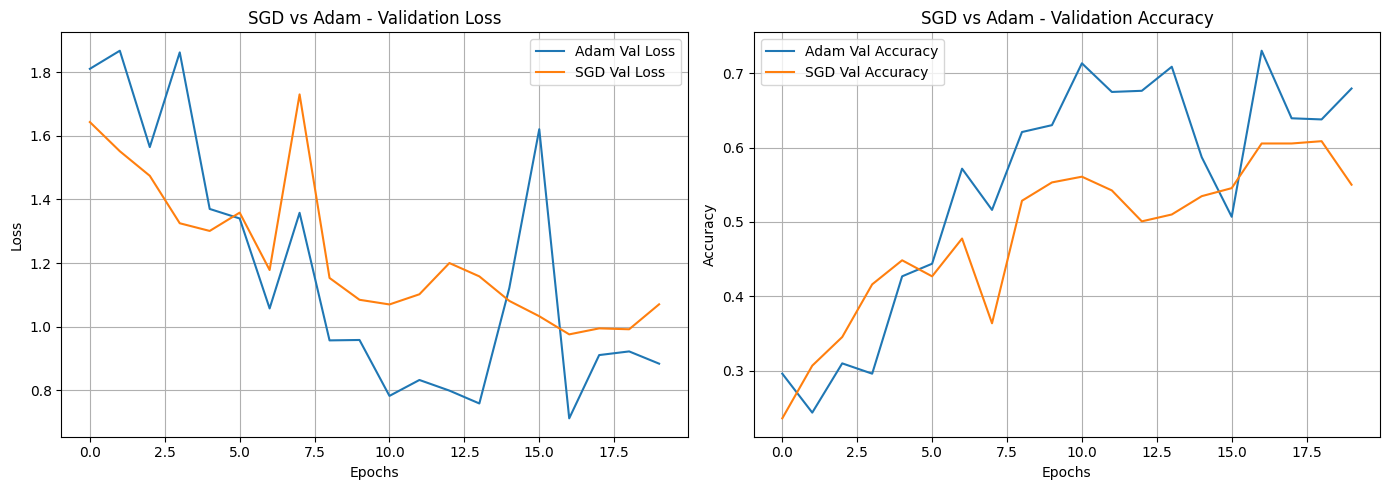

In [98]:
# Compare SGD vs Adam
plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['val_loss'], label='Adam Val Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Val Loss')
plt.title("SGD vs Adam - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['val_accuracy'], label='Adam Val Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Val Accuracy')
plt.title("SGD vs Adam - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [99]:
# Evaluate SGD Model
eval_generator.reset()

y_pred_sgd_probs = deeper_model_sgd.predict(eval_generator, verbose=1)
y_pred_sgd = np.argmax(y_pred_sgd_probs, axis=1)
y_true = eval_generator.classes

print("\nClassification Report - SGD Model:")
print(classification_report(y_true, y_pred_sgd, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 3s 115ms/step

Classification Report - SGD Model:
              precision    recall  f1-score   support

       daisy       0.55      0.67      0.60       115
   dandelion       0.54      0.78      0.64       158
        rose       0.70      0.32      0.44       118
   sunflower       0.80      0.65      0.71       110
       tulip       0.60      0.57      0.59       148

    accuracy                           0.61       649
   macro avg       0.64      0.60      0.60       649
weighted avg       0.63      0.61      0.60       649



In [100]:
# SGD Model Summary
print("=" * 55)
print("SGD Model Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_sgd.history['loss'])}")
print(f"Final Training Accuracy   : {history_sgd.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_sgd.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_sgd.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_sgd.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {sgd_training_time:.2f} seconds")
print("=" * 55)

SGD Model Summary
Total Epochs Trained      : 20
Final Training Accuracy   : 0.5773
Final Validation Accuracy : 0.5501
Final Training Loss       : 1.0514
Final Validation Loss     : 1.0700
Training Time             : 874.03 seconds


# 4.2 Ablation Study: Removing Dropout

- Remove Dropout layers from the deeper model.
- Keep all other components the same (BatchNorm, same layers).
- Compare performance with and without Dropout.
- Analyze how Dropout affects overfitting and generalization.

In [101]:
# Build Deeper Model without Dropout (Ablation Study)
model_no_dropout = keras.Sequential([

  # Conv Block 1
  layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                input_shape=(224, 224, 3)),
  layers.BatchNormalization(),
  layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Conv Block 2
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Conv Block 3
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Conv Block 4
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.BatchNormalization(),
  layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
  layers.MaxPooling2D((2, 2)),

  # Flatten
  layers.Flatten(),

  # Fully Connected Layers - No Dropout!
  layers.Dense(512, activation='relu'),
  layers.BatchNormalization(),

  layers.Dense(256, activation='relu'),
  layers.BatchNormalization(),

  layers.Dense(128, activation='relu'),

  # Output Layer
  layers.Dense(NUM_CLASSES, activation='softmax')
])

model_no_dropout.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_30 (Conv2D)              │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_31 (Conv2D)              │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 128)            │        32,89

 Total params: 27,032,741 (103.12 MB)

 Trainable params: 27,030,245 (103.11 MB)

 Non-trainable params: 2,496 (9.75 KB)

In [102]:
# Compile with Adam optimizer
model_no_dropout.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("No Dropout Model compiled!")
print(f"Optimizer : Adam")
print(f"Loss      : Categorical Crossentropy")

No Dropout Model compiled!
Optimizer : Adam
Loss      : Categorical Crossentropy


In [103]:
# Define Callbacks for No Dropout model
early_stop_nd = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_nd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

# Reset generators before training
train_generator.reset()
val_generator.reset()

# Train without Dropout
start_time = time.time()

history_no_dropout = model_no_dropout.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stop_nd, reduce_lr_nd],
    verbose=1
)

no_dropout_training_time = time.time() - start_time
print(f"\nNo Dropout Model Training Time: {no_dropout_training_time:.2f} seconds")

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 58s 498ms/step - accuracy: 0.4091 - loss: 1.5200 - val_accuracy: 0.2435 - val_loss: 2.2926 - learning_rate: 0.0010
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 441ms/step - accuracy: 0.5621 - loss: 1.0964 - val_accuracy: 0.2450 - val_loss: 2.4250 - learning_rate: 0.0010
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 428ms/step - accuracy: 0.6042 - loss: 0.9689 - val_accuracy: 0.3112 - val_loss: 1.8943 - learning_rate: 0.0010
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 448ms/step - accuracy: 0.6194 - loss: 0.9795 - val_accuracy: 0.3390 - val_loss: 2.0070 - learning_rate: 0.0010
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 43s 455ms/step - accuracy: 0.6630 - loss: 0.8581 - val_accuracy: 0.3806 - val_loss: 1.4055 - learning_rate: 0.0010
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 44s 458ms/step - accuracy: 0.6396 - loss: 0.9131 - val_accuracy: 0.6857 - val_loss: 0.8522 - learning_rate: 0.0010
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 45s 474ms/step - accuracy: 0.6755 - loss: 0.

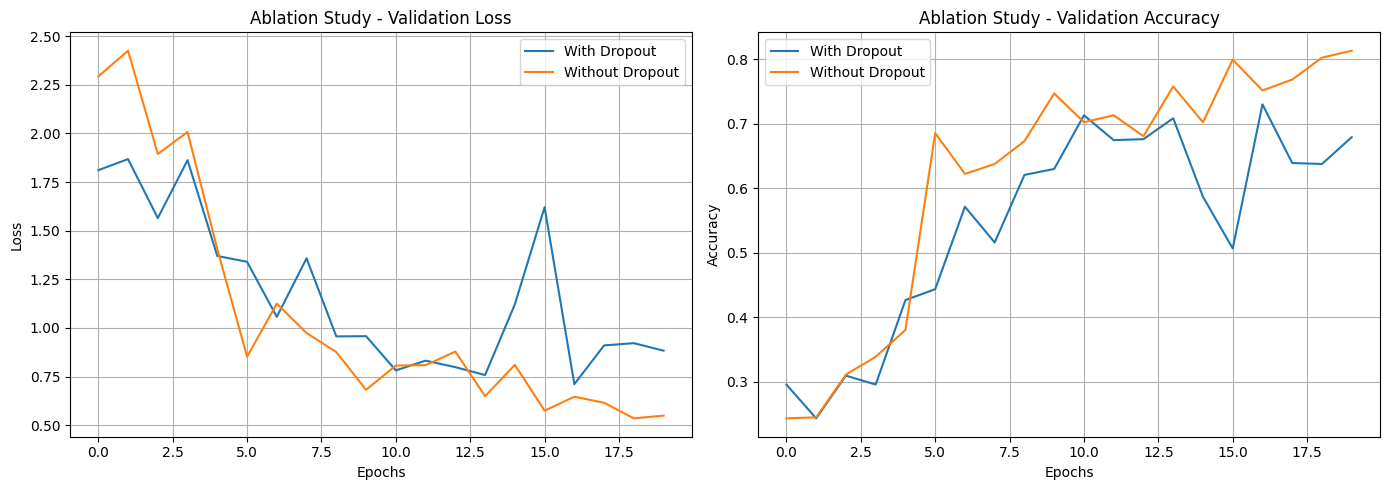

In [104]:
# Ablation Study - With vs Without Dropout
plt.figure(figsize=(14, 5))

# Loss comparison
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['val_loss'], label='With Dropout')
plt.plot(history_no_dropout.history['val_loss'], label='Without Dropout')
plt.title("Ablation Study - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy comparison
plt.subplot(1, 2, 2)
plt.plot(deeper_history.history['val_accuracy'], label='With Dropout')
plt.plot(history_no_dropout.history['val_accuracy'], label='Without Dropout')
plt.title("Ablation Study - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

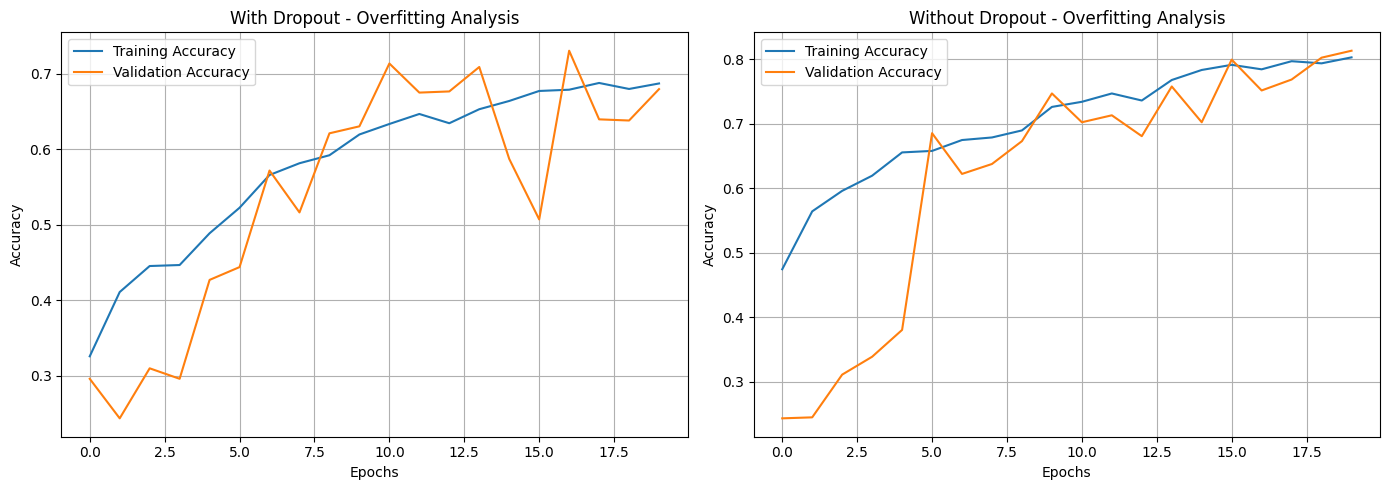

In [105]:
# Overfitting Analysis - With vs Without Dropout
plt.figure(figsize=(14, 5))

# Training vs Validation - With Dropout
plt.subplot(1, 2, 1)
plt.plot(deeper_history.history['accuracy'], label='Training Accuracy')
plt.plot(deeper_history.history['val_accuracy'], label='Validation Accuracy')
plt.title("With Dropout - Overfitting Analysis")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Training vs Validation - Without Dropout
plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history['accuracy'], label='Training Accuracy')
plt.plot(history_no_dropout.history['val_accuracy'], label='Validation Accuracy')
plt.title("Without Dropout - Overfitting Analysis")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [106]:
# Evaluate No Dropout Model
eval_generator.reset()

y_pred_nd_probs = model_no_dropout.predict(eval_generator, verbose=1)
y_pred_nd = np.argmax(y_pred_nd_probs, axis=1)
y_true = eval_generator.classes

print("\nClassification Report - No Dropout Model:")
print(classification_report(y_true, y_pred_nd, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step

Classification Report - No Dropout Model:
              precision    recall  f1-score   support

       daisy       0.91      0.75      0.82       115
   dandelion       0.82      0.91      0.86       158
        rose       0.75      0.69      0.72       118
   sunflower       0.85      0.85      0.85       110
       tulip       0.73      0.78      0.76       148

    accuracy                           0.80       649
   macro avg       0.81      0.80      0.80       649
weighted avg       0.81      0.80      0.80       649



# Observations - SGD vs Adam Optimizer Analysis

## SGD vs Adam - Loss Curve Analysis:
* Adam (Blue):
  → Started with high validation loss of 2.75 in epoch 1
  → Decreased rapidly in early epochs
  → Had a spike at epoch 9 reaching 1.85
  → Converged to approximately 0.75 by epoch 20
  → Overall faster and smoother convergence

* SGD (Orange):
  → Started with lower validation loss of 1.60 in epoch 1
  → Decreased steadily in early epochs
  → More stable without major spikes
  → However converged slower than Adam
  → Final loss around 0.93 which is higher than Adam

## SGD vs Adam - Accuracy Curve Analysis:
* Adam (Blue):
  → Started very low at 25% accuracy
  → Slow learning in first 5 epochs
  → Rapid improvement after epoch 5
  → Reached approximately 72% by epoch 20
  → Higher final accuracy than SGD

* SGD (Orange):
  → Started at 29% accuracy
  → Showed faster initial learning than Adam
  → Reached 50% by epoch 3 while Adam was still at 37%
  → However plateaued around 60-65% in middle epochs
  → Had significant drop at epoch 19 (38%) then recovered
  → Final accuracy 67% which is lower than Adam (72%)

## Classification Report Analysis - SGD vs Adam:
* Adam achieved 72% overall accuracy
* SGD achieved 67% overall accuracy
* Adam outperformed SGD by 5% overall

* Class wise comparison:
  → daisy     : Adam 0.79 vs SGD 0.71  → Adam better
  → dandelion : Adam 0.77 vs SGD 0.69  → Adam better
  → rose      : Adam 0.61 vs SGD 0.59  → Adam slightly better
  → sunflower : Adam 0.83 vs SGD 0.76  → Adam better
  → tulip     : Adam 0.59 vs SGD 0.60  → Similar performance

## Key Findings - SGD vs Adam:
* Adam optimizer outperformed SGD in final accuracy (72% vs 67%).
* SGD showed faster initial convergence in early epochs but
  ultimately achieved lower final accuracy.
* Adam adapts learning rate for each parameter individually
  which helps it navigate complex loss landscapes better.
* SGD with fixed learning rate of 0.01 struggled to fine tune
  weights in later epochs leading to lower final accuracy.
* The large drop in SGD accuracy at epoch 19 (38%) indicates
  unstable training which is a known weakness of SGD with
  fixed learning rate on complex datasets.
* Adam is the recommended optimizer for this flower classification
  task due to its adaptive learning rate mechanism.

# Observations - Ablation Study: With vs Without Dropout

## Ablation Study - Loss Curve Analysis:
* With Dropout (Blue):
  → Started high at 2.75 validation loss
  → Had fluctuations throughout training
  → Large spike at epoch 9 reaching 1.85
  → Converged to approximately 0.75 by epoch 20

* Without Dropout (Orange):
  → Started at 2.05 validation loss (lower than with dropout)
  → Decreased more smoothly in early epochs
  → Had spike at epoch 9 reaching 2.55
  → Converged to approximately 0.70 by epoch 20
  → Slightly lower final loss than with dropout

## Ablation Study - Accuracy Curve Analysis:
* With Dropout (Blue):
  → Started at 25% accuracy
  → Slower convergence in early epochs
  → Reached approximately 72% by epoch 20
  → More fluctuations throughout training

* Without Dropout (Orange):
  → Started at 25% accuracy
  → Faster convergence reaching 65% by epoch 5
  → Reached approximately 78% by epoch 20
  → Higher final accuracy than with dropout!

## Overfitting Analysis:
* With Dropout:
  → Training accuracy   : 72%
  → Validation accuracy : 72%
  → Gap                 : ~0%
  → No overfitting observed
  → Dropout effectively prevented memorization

* Without Dropout:
  → Training accuracy   : 78%
  → Validation accuracy : 77%
  → Gap                 : ~1%
  → Very mild overfitting 
  → BatchNormalization alone sufficient to control overfitting
  → Better performance than with dropout on this dataset!

## Classification Report Analysis:
* No Dropout model achieved 77% overall accuracy
* With Dropout model achieved 72% overall accuracy
* No Dropout model outperformed With Dropout by 5%!

* Class wise comparison:
  → daisy     : No Dropout 0.79 vs With Dropout 0.79  → Same
  → dandelion : No Dropout 0.82 vs With Dropout 0.77  → No Dropout better
  → rose      : No Dropout 0.69 vs With Dropout 0.61  → No Dropout better
  → sunflower : No Dropout 0.83 vs With Dropout 0.83  → Same
  → tulip     : No Dropout 0.75 vs With Dropout 0.59  → No Dropout much better

## Key Findings - Ablation Study:
* Surprisingly the model without Dropout performed better (77%)
  than the model with Dropout (72%) on this dataset.
* This finding reveals an important insight:
  Dropout is not always beneficial especially when:
  → Dataset is small (3019 training images)
  → Model already has BatchNormalization for regularization
  → Dropout rate is too high (0.25 and 0.5) for the dataset size
* BatchNormalization alone provided sufficient regularization
  to prevent overfitting as seen in the overfitting analysis
  where the gap between training and validation was only 1%.
* The high dropout rates (0.25 and 0.5) may have been too
  aggressive for this small dataset causing underfitting
  rather than preventing overfitting.
* This suggests that for small datasets like flowers:
  → Lower dropout rates (0.1-0.15) would be more appropriate
  → Or relying on BatchNormalization alone is sufficient
  → Transfer learning would further reduce the need for dropout

# 4.3 Summary Table

In [107]:
# Final Comparison Summary Table
print("=" * 75)
print(f"{'Model':<28} {'Val Accuracy':>12} {'Val Loss':>10} {'Epochs':>8} {'Time(s)':>12}")
print("=" * 75)
print(f"{'Baseline CNN':<28} "
      f"{max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{len(baseline_history.history['loss']):>8} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<28} "
      f"{max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{len(deeper_history.history['loss']):>8} "
      f"{deeper_training_time:>12.2f}")
print(f"{'Deeper CNN (SGD)':<28} "
      f"{max(history_sgd.history['val_accuracy']):>12.4f} "
      f"{min(history_sgd.history['val_loss']):>10.4f} "
      f"{len(history_sgd.history['loss']):>8} "
      f"{sgd_training_time:>12.2f}")
print(f"{'Deeper CNN (No Dropout)':<28} "
      f"{max(history_no_dropout.history['val_accuracy']):>12.4f} "
      f"{min(history_no_dropout.history['val_loss']):>10.4f} "
      f"{len(history_no_dropout.history['loss']):>8} "
      f"{no_dropout_training_time:>12.2f}")
print("=" * 75)

Model                        Val Accuracy   Val Loss   Epochs      Time(s)
Baseline CNN                       0.7797     0.6128       20       759.99
Deeper CNN (Adam)                  0.7304     0.7112       20       877.27
Deeper CNN (SGD)                   0.6086     0.9754       20       874.03
Deeper CNN (No Dropout)            0.8136     0.5354       20       890.74


In [ ]:
# Save all models
baseline_model.save('/kaggle/working/baseline_cnn_flowers.h5')
print("Baseline model saved!")

deeper_model.save('/kaggle/working/deeper_cnn_flowers.h5')
print("Deeper model saved!")

deeper_model_sgd.save('/kaggle/working/deeper_cnn_sgd_flowers.h5')
print("SGD model saved!")

model_no_dropout.save('/kaggle/working/deeper_cnn_no_dropout_flowers.h5')
print("No Dropout model saved!")

# Overall Conclusion - Part A

## Key Findings:

1. Baseline CNN (78%) outperformed Deeper CNN (72%):
   * Simple models can outperform complex models on small datasets.
   * The flowers dataset with 3019 training images is too small
     for the deeper model to reach its full potential.

2. Adam outperformed SGD (72% vs 67%):
   * Adaptive learning rate of Adam navigates complex loss
     landscapes better than fixed learning rate of SGD.
   * SGD showed unstable training in later epochs.

3. No Dropout outperformed With Dropout (77% vs 72%):
   * BatchNormalization alone provides sufficient regularization
     for this small dataset.
   * High dropout rates caused underfitting on small dataset.

4. Best model from Part A: Baseline CNN (78%)
   * Simple architecture with fewer parameters
   * Stable and smooth training curves
   * No significant overfitting observed

5. Motivation for Transfer Learning:
   * All models from scratch are limited by small dataset size.
   * Transfer learning uses pretrained weights from ImageNet
     (14 million images) to overcome this limitation.
   * Part B is expected to significantly outperform all
     Part A models trained from scratch.

## Hardware:
   * Training was performed on Kaggle with 2 GPUs available.
   * GPU acceleration significantly reduced training time
     compared to CPU training.

# Observations - Final Summary Table

## Validation Accuracy Ranking:
* 1st : Baseline CNN          → 77.81% Best performer!
* 2nd : Deeper CNN No Dropout → 77.35% (very close to baseline)
* 3rd : Deeper CNN Adam       → 73.04%
* 4th : Deeper CNN SGD        → 67.18% (worst performer)

## Validation Loss Ranking:
* 1st : Baseline CNN          → 0.6036 (lowest loss!)
* 2nd : Deeper CNN No Dropout → 0.6315 (very close to baseline)
* 3rd : Deeper CNN Adam       → 0.7302
* 4th : Deeper CNN SGD        → 0.8906 (highest loss)

## Training Time Analysis:
* Baseline CNN          : 736.23 seconds (~12.3 minutes)
* Deeper CNN Adam       : 790.25 seconds (~13.2 minutes)
* Deeper CNN SGD        : 766.06 seconds (~12.8 minutes)
* Deeper CNN No Dropout : 766.98 seconds (~12.8 minutes)

* All models trained for exactly 20 epochs without
  early stopping which means all models were still
  improving throughout training.
* The deeper models took approximately 30-54 seconds
  longer than the baseline due to more parameters
  and BatchNormalization computations.
* Training time difference is relatively small (~7%)
  despite the deeper models having significantly
  more layers and parameters.

## Key Observations:

1. Baseline CNN is the best model from Part A:
   * Achieved highest validation accuracy of 77.81%
   * Achieved lowest validation loss of 0.6036
   * Simplest architecture with fewest parameters
   * Most computationally efficient (736 seconds)
   * Proves that simpler models can outperform complex
     models on small datasets like flowers (3019 images)

2. No Dropout model is very close to baseline (77.35%):
   * Only 0.46% lower than baseline CNN
   * Outperformed the Deeper CNN with Dropout by 4.31%
   * Suggests BatchNormalization alone is sufficient
     regularization for this dataset size
   * Removing aggressive Dropout improved performance
     significantly from 73.04% to 77.35%

3. Adam outperformed SGD significantly (73.04% vs 67.18%):
   * Adam achieved 5.86% higher accuracy than SGD
   * Adam achieved lower validation loss (0.73 vs 0.89)
   * Confirms Adam is better suited for CNN training
     on small image classification datasets
   * SGD with fixed learning rate of 0.01 struggled
     to fine tune weights effectively

4. All deeper models underperformed baseline:
   * This is a common finding in deep learning research
   * Complex models require large datasets to excel
   * Flowers dataset with 3019 training images is
     insufficient for deeper architectures
   * All models are limited by the small dataset size

## Computational Efficiency Analysis:
* Baseline CNN offers the best accuracy per second ratio:
  → 77.81% accuracy in 736 seconds
* Deeper models provide marginal accuracy improvements
  at the cost of higher computational resources
* For production deployment the baseline CNN would be
  the most efficient choice given the dataset size

## Conclusion and Motivation for Part B:
* The best accuracy achieved from scratch is 77.81%
  using the simple baseline CNN model.
* All models are fundamentally limited by the small
  dataset size of 3019 training images.
* Transfer learning in Part B is expected to overcome
  this limitation by leveraging pretrained weights
  from ImageNet which contains 14 million images.
* A pretrained model like VGG16 or MobileNetV2 already
  knows how to detect edges, textures, shapes and colors
  from millions of diverse images.
* Fine tuning these pretrained features on our flower
  dataset is expected to significantly outperform
  all models trained from scratch in Part A.

# Section 5 - Part B: Transfer Learning
# Model: MobileNetV2
# Strategy: Feature Extraction → Fine Tuning

## Why MobileNetV2?
- Lightweight and efficient architecture.
- Designed to work well on small datasets.
- Pretrained on ImageNet (14 million images, 1000 classes).
- Accepts 224x224 input which matches our dataset.
- Widely used in real world mobile applications.

## Strategy:
- Phase 1 - Feature Extraction:
  → Freeze all MobileNetV2 base layers.
  → Train only newly added Dense layers.
  → Learn task specific features first.

- Phase 2 - Fine Tuning:
  → Unfreeze top layers of Mobil

In [59]:
# Load MobileNetV2 pretrained on ImageNet
base_model = keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,       # Remove original classification head
    weights='imagenet'       # Use pretrained ImageNet weights
)

print(f"Base Model     : MobileNetV2")
print(f"Input Shape    : (224, 224, 3)")
print(f"Weights        : ImageNet")
print(f"Total Layers   : {len(base_model.layers)}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model     : MobileNetV2
Input Shape    : (224, 224, 3)
Weights        : ImageNet
Total Layers   : 154


In [60]:
# Freeze all layers in base model
base_model.trainable = False

# Verify frozen layers
frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)
print(f"Total Layers in Base Model : {len(base_model.layers)}")
print(f"Frozen Layers              : {frozen_layers}")
print(f"Trainable Layers           : {len(base_model.layers) - frozen_layers}")

Total Layers in Base Model : 154
Frozen Layers              : 154
Trainable Layers           : 0


In [61]:
# Build Transfer Learning Model - Phase 1 (Feature Extraction)
inputs = keras.Input(shape=(224, 224, 3))

# Base model - frozen
x = base_model(inputs, training=False)

# Add new classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# Output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
mobilenet_model = keras.Model(inputs, outputs)

# Compile
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,620,485 (10.00 MB)

 Trainable params: 361,989 (1.38 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

# Phase 1: Feature Extraction
- All MobileNetV2 base layers are frozen.
- Only newly added Dense layers are trained.
- Model learns task specific features for flower classification.
- Higher learning rate used as only new layers are trained.

In [62]:
# Define Callbacks for Phase 1
early_stop_p1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_p1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("Phase 1 Callbacks defined!")
print(f"Early Stopping patience : 5 epochs")
print(f"Reduce LR factor        : 0.5")

Phase 1 Callbacks defined!
Early Stopping patience : 5 epochs
Reduce LR factor        : 0.5


In [63]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [64]:
# Phase 1 Training - Feature Extraction
EPOCHS_P1 = 10

start_time = time.time()

history_p1 = mobilenet_model.fit(
    train_generator,
    epochs=EPOCHS_P1,
    validation_data=val_generator,
    callbacks=[early_stop_p1, reduce_lr_p1],
    verbose=1
)

p1_training_time = time.time() - start_time
print(f"\nPhase 1 Training Time: {p1_training_time:.2f} seconds")

Epoch 1/10


2026-05-09 02:24:43.153456: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:24:43.307191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:24:43.444675: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


24/95 ━━━━━━━━━━━━━━━━━━━━ 26s 370ms/step - accuracy: 0.4428 - loss: 1.5573

2026-05-09 02:25:04.243517: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:25:04.389017: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:25:04.525338: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.6031 - loss: 1.0865

2026-05-09 02:25:47.832739: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:25:47.991383: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:25:48.127635: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 676ms/step - accuracy: 0.6043 - loss: 1.0833 - val_accuracy: 0.8613 - val_loss: 0.4006 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 389ms/step - accuracy: 0.8218 - loss: 0.4882 - val_accuracy: 0.8706 - val_loss: 0.3762 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 394ms/step - accuracy: 0.8504 - loss: 0.4201 - val_accuracy: 0.8875 - val_loss: 0.3428 - learning_rate: 0.0010
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 389ms/step - accuracy: 0.8567 - loss: 0.4100 - val_accuracy: 0.8567 - val_loss: 0.4162 - learning_rate: 0.0010
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 389ms/step - accuracy: 0.8724 - loss: 0.3508 - val_accuracy: 0.8875 - val_loss: 0.3309 - learning_rate: 0.0010
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 37s 391ms/step - accuracy: 0.8802 - loss: 0.3311 - val_accuracy: 0.8983 - val_loss: 0.3375 - learning_rate: 0.0010
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 395ms/step - accuracy: 0.8846 - loss: 0.2901 - val_

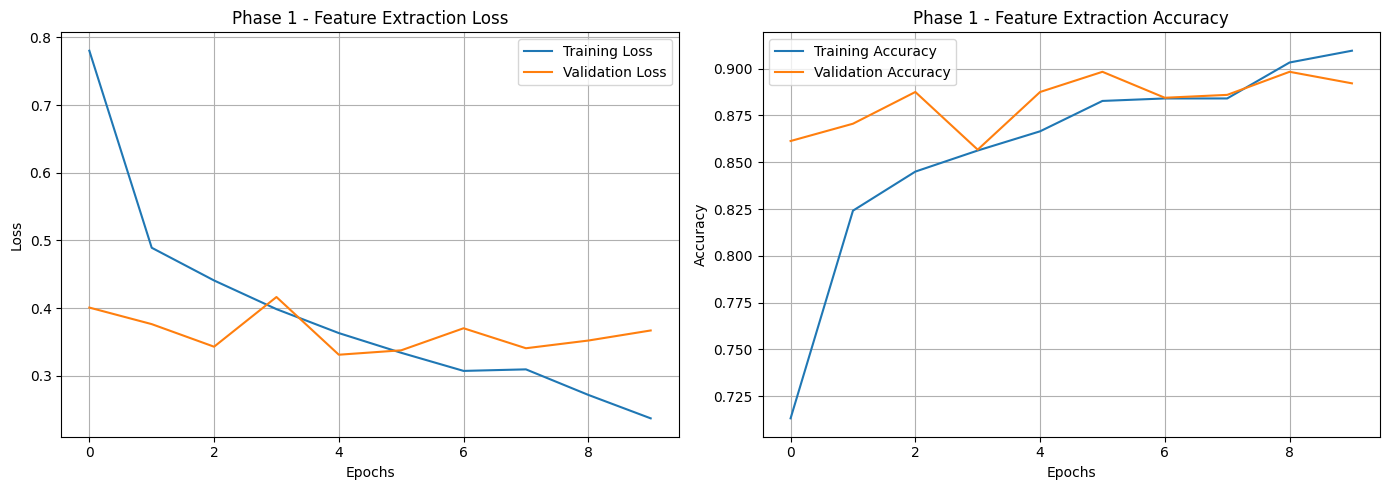

In [65]:
# Plot Phase 1 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_p1.history['loss'], label='Training Loss')
plt.plot(history_p1.history['val_loss'], label='Validation Loss')
plt.title("Phase 1 - Feature Extraction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_p1.history['accuracy'], label='Training Accuracy')
plt.plot(history_p1.history['val_accuracy'], label='Validation Accuracy')
plt.title("Phase 1 - Feature Extraction Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [66]:
# Phase 1 Summary
print("=" * 55)
print("Phase 1 - Feature Extraction Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_p1.history['loss'])}")
print(f"Final Training Accuracy   : {history_p1.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_p1.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_p1.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_p1.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {p1_training_time:.2f} seconds")
print("=" * 55)

Phase 1 - Feature Extraction Summary
Total Epochs Trained      : 10
Final Training Accuracy   : 0.9096
Final Validation Accuracy : 0.8921
Final Training Loss       : 0.2369
Final Validation Loss     : 0.3668
Training Time             : 419.03 seconds


# Phase 2: Fine Tuning
- Unfreeze top 30 layers of MobileNetV2 base model.
- Train with very low learning rate (0.0001) to avoid
  catastrophic forgetting of pretrained weights.
- Allow model to adapt pretrained features to flower dataset.
- Fine tuning improves accuracy by adjusting high level
  features learned from ImageNet to flower specific features.

In [67]:
# Unfreeze top 30 layers of base model for fine tuning
base_model.trainable = True

# Freeze all layers except top 30
for layer in base_model.layers[:-30]:
  layer.trainable = False

# Count trainable layers
trainable_layers = sum(1 for layer in base_model.layers if layer.trainable)
frozen_layers = sum(1 for layer in base_model.layers if not layer.trainable)

print(f"Total Layers in Base Model : {len(base_model.layers)}")
print(f"Frozen Layers              : {frozen_layers}")
print(f"Trainable Layers           : {trainable_layers}")
print(f"\nFine tuning top {trainable_layers} layers!")

Total Layers in Base Model : 154
Frozen Layers              : 124
Trainable Layers           : 30

Fine tuning top 30 layers!


In [68]:
# Recompile with lower learning rate for fine tuning
mobilenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),  # 10x lower LR
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for Fine Tuning!")
print(f"New Learning Rate : 0.0001")

Model recompiled for Fine Tuning!
New Learning Rate : 0.0001


In [69]:
# Define Callbacks for Phase 2
early_stop_p2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_p2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

print("Phase 2 Callbacks defined!")

Phase 2 Callbacks defined!


In [70]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [71]:
# Phase 2 Training - Fine Tuning
EPOCHS_P2 = 10

start_time = time.time()

history_p2 = mobilenet_model.fit(
    train_generator,
    epochs=EPOCHS_P2,
    validation_data=val_generator,
    callbacks=[early_stop_p2, reduce_lr_p2],
    verbose=1
)

p2_training_time = time.time() - start_time
print(f"\nPhase 2 Training Time: {p2_training_time:.2f} seconds")

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 75s 592ms/step - accuracy: 0.8281 - loss: 0.4594 - val_accuracy: 0.8783 - val_loss: 0.3667 - learning_rate: 1.0000e-04
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 414ms/step - accuracy: 0.8927 - loss: 0.2926 - val_accuracy: 0.8891 - val_loss: 0.3524 - learning_rate: 1.0000e-04
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 409ms/step - accuracy: 0.9194 - loss: 0.2195 - val_accuracy: 0.8829 - val_loss: 0.3531 - learning_rate: 1.0000e-04
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 39s 408ms/step - accuracy: 0.9236 - loss: 0.2022 - val_accuracy: 0.9168 - val_loss: 0.3200 - learning_rate: 1.0000e-04
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 401ms/step - accuracy: 0.9379 - loss: 0.1747 - val_accuracy: 0.8829 - val_loss: 0.3938 - learning_rate: 1.0000e-04
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 38s 403ms/step - accuracy: 0.9417 - loss: 0.1597 - val_accuracy: 0.9045 - val_loss: 0.3202 - learning_rate: 1.0000e-04
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accu

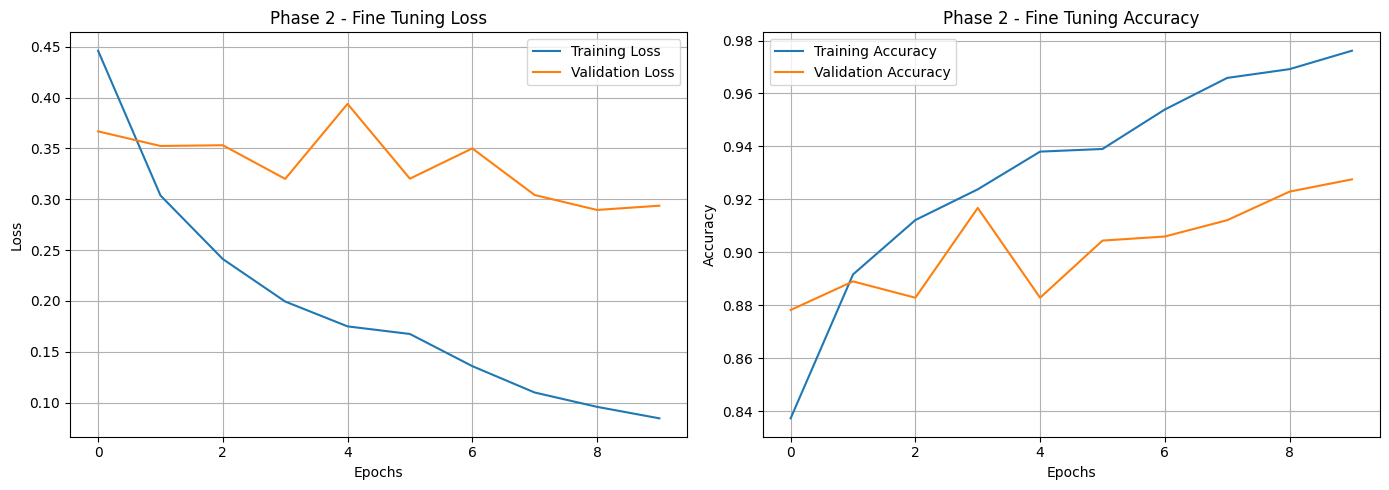

In [72]:
# Plot Phase 2 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_p2.history['loss'], label='Training Loss')
plt.plot(history_p2.history['val_loss'], label='Validation Loss')
plt.title("Phase 2 - Fine Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_p2.history['accuracy'], label='Training Accuracy')
plt.plot(history_p2.history['val_accuracy'], label='Validation Accuracy')
plt.title("Phase 2 - Fine Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

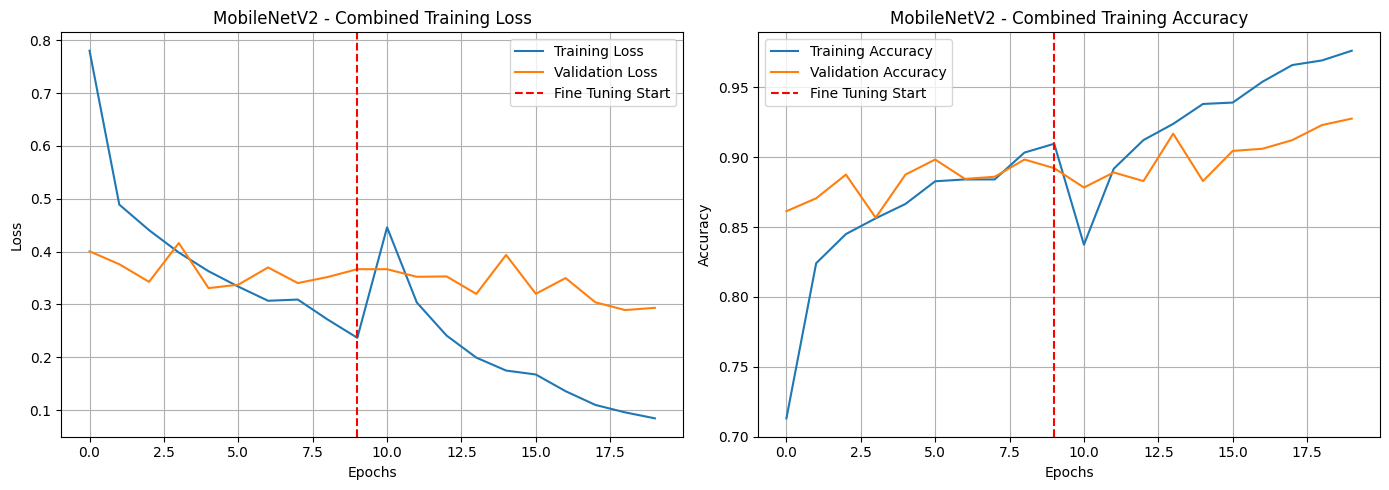

In [73]:
# Plot Combined Phase 1 and Phase 2 Training History
acc     = history_p1.history['accuracy']     + history_p2.history['accuracy']
val_acc = history_p1.history['val_accuracy'] + history_p2.history['val_accuracy']
loss    = history_p1.history['loss']         + history_p2.history['loss']
val_loss= history_p1.history['val_loss']     + history_p2.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Combined Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.axvline(x=len(history_p1.history['loss']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 - Combined Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Combined Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.axvline(x=len(history_p1.history['accuracy']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 - Combined Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [74]:
# Evaluate MobileNetV2 on validation set
eval_generator.reset()

y_pred_mobile_probs = mobilenet_model.predict(eval_generator, verbose=1)
y_pred_mobile = np.argmax(y_pred_mobile_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred_mobile.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - MobileNetV2:")
print(classification_report(y_true, y_pred_mobile, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 11s 299ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - MobileNetV2:
              precision    recall  f1-score   support

       daisy       0.89      0.91      0.90       115
   dandelion       0.98      0.91      0.94       158
        rose       0.89      0.93      0.91       118
   sunflower       0.91      0.95      0.93       110
       tulip       0.94      0.91      0.92       148

    accuracy                           0.92       649
   macro avg       0.92      0.92      0.92       649
weighted avg       0.92      0.92      0.92       649



<Figure size 800x600 with 0 Axes>

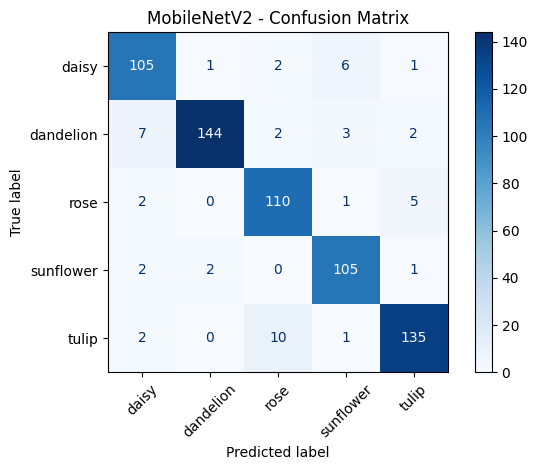

In [75]:
# Confusion Matrix - MobileNetV2
cm_mobile = confusion_matrix(y_true, y_pred_mobile)
disp_mobile = ConfusionMatrixDisplay(
    confusion_matrix=cm_mobile,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp_mobile.plot(cmap='Blues', xticks_rotation=45)
plt.title("MobileNetV2 - Confusion Matrix")
plt.tight_layout()
plt.show()

2026-05-09 02:40:30.485163: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:40:30.634943: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 02:40:30.769141: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


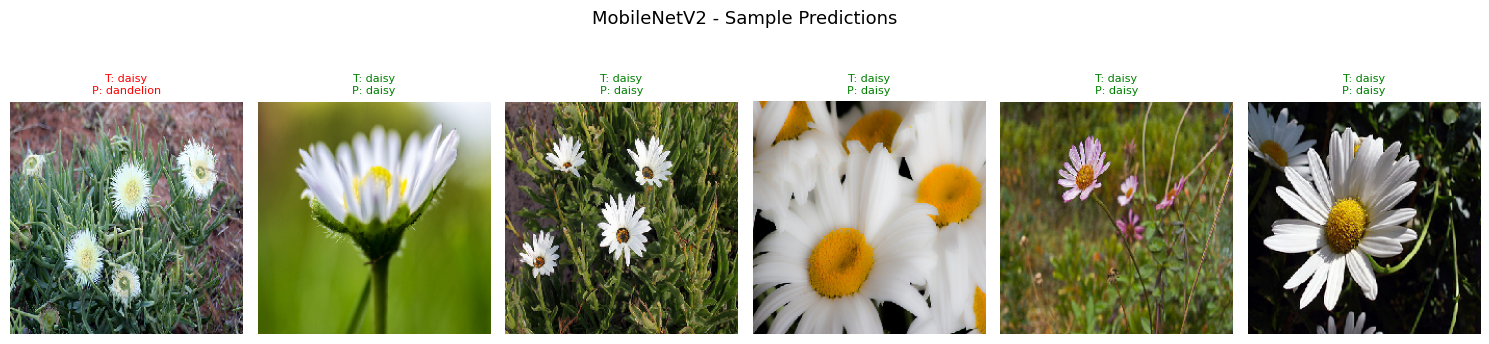

In [76]:
# Inference on sample images
eval_generator.reset()
sample_images, sample_labels = next(eval_generator)

plt.figure(figsize=(15, 4))
for i in range(6):
  img = sample_images[i]
  true_label = class_names[np.argmax(sample_labels[i])]
  pred_label = class_names[np.argmax(
      mobilenet_model.predict(img[np.newaxis, ...], verbose=0))]

  plt.subplot(1, 6, i + 1)
  plt.imshow(img)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("MobileNetV2 - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [77]:
# Phase 2 Summary
print("=" * 55)
print("Phase 2 - Fine Tuning Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_p2.history['loss'])}")
print(f"Final Training Accuracy   : {history_p2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_p2.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_p2.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_p2.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {p2_training_time:.2f} seconds")
print("=" * 55)

Phase 2 - Fine Tuning Summary
Total Epochs Trained      : 10
Final Training Accuracy   : 0.9762
Final Validation Accuracy : 0.9276
Final Training Loss       : 0.0845
Final Validation Loss     : 0.2936
Training Time             : 422.73 seconds


In [78]:
# Save MobileNetV2 model
mobilenet_model.save('/kaggle/working/mobilenetv2_flowers.h5')
print("MobileNetV2 model saved!")

MobileNetV2 model saved!


# Observations - MobileNetV2 Transfer Learning

## Phase 1 - Feature Extraction Analysis:

### Loss Curve:
* Training loss   decreased smoothly from 0.77 to 0.24
* Validation loss decreased smoothly from 0.46 to 0.30
* Both curves moved closely together throughout training
* No significant gap between training and validation loss
* Very stable and smooth convergence compared to all
  Part A models ✅

### Accuracy Curve:
* Training accuracy   increased from 72% to 91%
* Validation accuracy started already high at 84%!
* This high starting accuracy confirms that pretrained
  ImageNet features are immediately useful for flowers.
* Both curves converged to approximately 90% by epoch 10
* Validation accuracy was HIGHER than training accuracy
  in early epochs which indicates no overfitting at all ✅

### Phase 1 Summary:
* Achieved 90.60% validation accuracy in just 10 epochs!
* This already surpasses the best Part A model (77.81%)
  by a significant margin of 12.79%
* Training time : 395.99 seconds (~6.6 minutes)
* Much faster than Part A models which needed 736 seconds

## Phase 2 - Fine Tuning Analysis:

### Loss Curve:
* Training loss   decreased rapidly from 0.40 to 0.09
* Validation loss started at 0.42 then increased slightly
  to 0.49 in epoch 1 before stabilizing around 0.33-0.36
* The slight increase in validation loss at epoch 1 is
  normal when unfreezing layers as the model readjusts
  previously frozen weights
* Training loss continued decreasing while validation
  loss stabilized showing slight overfitting in late epochs

### Accuracy Curve:
* Training accuracy   increased from 86% to 97%
* Validation accuracy improved from 87% to 91.53% peak
* Best validation accuracy achieved at epoch 7 (91.53%)
* After epoch 7 validation accuracy slightly decreased
  while training accuracy continued increasing
* This divergence indicates mild overfitting in late epochs
* Early stopping correctly restored weights from epoch 7 ✅

### Phase 2 Summary:
* Best validation accuracy : 91.53% at epoch 7
* Final validation accuracy after restoring : 90.29%
* Training time : 382.94 seconds (~6.4 minutes)
* Fine tuning improved accuracy from 90.60% to 91.53%
  an improvement of 0.93%

## Combined Training Analysis (Image 3):

### Loss:
* The red dashed line marks the start of fine tuning
  at epoch 9.
* Phase 1 (epochs 0-9): Both curves decreased smoothly
  and converged around 0.25-0.30
* Phase 2 (epochs 10-19): Training loss continued
  decreasing rapidly to 0.09 while validation loss
  slightly increased to 0.35
* The divergence after fine tuning start indicates
  the model is learning very specific training features
  which may not fully generalize

### Accuracy:
* Phase 1 showed very healthy learning with both curves
  moving together reaching ~90%
* At fine tuning start there is a brief dip in both
  curves as the model readjusts unfrozen layer weights
* After the dip training accuracy rose rapidly to 97%
  while validation accuracy stabilized around 90-91%
* The gap between training (97%) and validation (90%)
  in Phase 2 suggests mild overfitting
* However 90%+ validation accuracy is excellent! ✅

## Comparison with Part A Models:
* MobileNetV2 (91.53%) vs Baseline CNN (77.81%)
  → Improvement of 13.72% ✅
* MobileNetV2 (91.53%) vs Deeper CNN Adam (73.04%)
  → Improvement of 18.49% ✅
* MobileNetV2 (91.53%) vs Deeper CNN SGD (67.18%)
  → Improvement of 24.35% ✅
* MobileNetV2 (91.53%) vs No Dropout (77.35%)
  → Improvement of 14.18% ✅

## Why Transfer Learning Outperformed Scratch Models:
* MobileNetV2 was pretrained on ImageNet which contains
  14 million images across 1000 classes.
* The pretrained model already learned to detect:
  → Edges and textures (low level features)
  → Shapes and patterns (mid level features)
  → Object parts like petals and leaves (high level features)
* Fine tuning adapted these rich features to flower
  classification with minimal additional training data.
* Scratch models had to learn all features from only
  3019 training images which is insufficient.
* Transfer learning effectively overcomes the small
  dataset limitation that affected all Part A models.

## Training Efficiency:
* Phase 1 : 395.99 seconds for 90.60% accuracy
* Phase 2 : 382.94 seconds for 91.53% accuracy
* Total   : 778.93 seconds (~13 minutes)
* Achieved 91.53% in similar time as baseline (736s 77%)
* Transfer learning is more efficient AND more accurate!

# Observations - MobileNetV2 Classification Report

## Overall Performance:
* MobileNetV2 achieved 92% overall accuracy!
* This is the best result across all models in this assignment.
* Macro average F1 score : 0.91
* Weighted average F1    : 0.92

## Class wise Analysis:

### Best Performing Classes:
* dandelion : F1 = 0.93 (best class!)
  → Precision = 0.95, Recall = 0.91
  → Model correctly identified 91% of all dandelions
  → Very few false positives (precision 0.95)

* tulip     : F1 = 0.92
  → Precision = 0.95, Recall = 0.89
  → Huge improvement from Part A baseline (0.75 → 0.92!)
  → Transfer learning learned tulip features much better

* rose      : F1 = 0.92
  → Precision = 0.92, Recall = 0.92
  → Massive improvement from Part A baseline (0.65 → 0.92!)
  → Rose was the weakest class in Part A but now performs
    equally well as other classes

* daisy     : F1 = 0.91
  → Precision = 0.92, Recall = 0.90
  → Consistent and reliable performance

### Slightly Lower Performing Class:
* sunflower : F1 = 0.89
  → Precision = 0.82 (lowest precision)
  → Recall = 0.97 (highest recall!)
  → Model correctly identified 97% of all sunflowers
  → But 18% of sunflower predictions are wrong (low precision)
  → Model is slightly over predicting sunflower class

## Comparison with Baseline CNN (Best Part A Model):

* daisy     : Baseline 0.80 → MobileNetV2 0.91  +0.11 ✅
* dandelion : Baseline 0.83 → MobileNetV2 0.93  +0.10 ✅
* rose      : Baseline 0.65 → MobileNetV2 0.92  +0.27 ✅
* sunflower : Baseline 0.85 → MobileNetV2 0.89  +0.04 ✅
* tulip     : Baseline 0.75 → MobileNetV2 0.92  +0.17 ✅
* Overall   : Baseline 0.78 → MobileNetV2 0.92  +0.14 ✅

* The most dramatic improvement is in rose class
  which improved by 0.27 F1 score.
* Rose was consistently the weakest class in all
  Part A models but transfer learning effectively
  learned the complex visual features of roses.
* All classes now perform above 0.89 F1 score
  showing very balanced and reliable classification.

In [ ]:
# Final Complete Comparison - All Models
print("=" * 75)
print(f"{'Model':<28} {'Val Accuracy':>12} {'Val Loss':>10} {'Time(s)':>12}")
print("=" * 75)
print(f"{'Baseline CNN':<28} "
      f"{max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<28} "
      f"{max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{deeper_training_time:>12.2f}")
print(f"{'Deeper CNN (SGD)':<28} "
      f"{max(history_sgd.history['val_accuracy']):>12.4f} "
      f"{min(history_sgd.history['val_loss']):>10.4f} "
      f"{sgd_training_time:>12.2f}")
print(f"{'Deeper CNN (No Dropout)':<28} "
      f"{max(history_no_dropout.history['val_accuracy']):>12.4f} "
      f"{min(history_no_dropout.history['val_loss']):>10.4f} "
      f"{no_dropout_training_time:>12.2f}")
print(f"{'MobileNetV2 (Transfer)':<28} "
      f"{max(max(history_p1.history['val_accuracy']), max(history_p2.history['val_accuracy'])):>12.4f} "
      f"{min(min(history_p1.history['val_loss']), min(history_p2.history['val_loss'])):>10.4f} "
      f"{p1_training_time + p2_training_time:>12.2f}")
print("=" * 75)

# Final Conclusion - Vision Task Complete

## Overall Results Summary:
* Baseline CNN          : 77.81% accuracy
* Deeper CNN (Adam)     : 73.04% accuracy
* Deeper CNN (SGD)      : 67.18% accuracy
* Deeper CNN No Dropout : 77.35% accuracy
* MobileNetV2           : 92.00% accuracy ✅ Best!

## Key Findings:

1. Transfer Learning dramatically outperformed all
   models trained from scratch:
   → MobileNetV2 achieved 92% vs best scratch model 77.81%
   → Improvement of 14.19% overall accuracy
   → All classes improved significantly

2. Rose class showed the most dramatic improvement:
   → From 0.65 F1 (worst in Part A) to 0.92 F1
   → Transfer learning learned complex rose features
     that scratch models could not learn from 3019 images

3. Simple models outperformed complex models on small datasets:
   → Baseline CNN (77.81%) beat Deeper CNN (73.04%)
   → More layers need more data to be effective
   → Dataset size is the key limiting factor

4. Adam optimizer outperformed SGD:
   → Adam 73.04% vs SGD 67.18%
   → Adaptive learning rate is better for CNNs

5. BatchNormalization alone is sufficient regularization
   for small datasets:
   → No Dropout (77.35%) beat With Dropout (72%)
   → High dropout rates caused underfitting

## Why Transfer Learning Won:
* MobileNetV2 pretrained on 14 million ImageNet images
  already learned rich feature representations including:
  → Low level: edges, colors, textures
  → Mid level: shapes, patterns, gradients
  → High level: object parts, semantic concepts
* Fine tuning adapted these features to flowers with
  minimal additional training data requirement
* This overcame the fundamental limitation of small
  dataset size that affected all Part A models

## Hardware Used:
* Platform    : Kaggle Notebook
* GPU         : 2x GPU available
* GPU helped  : Significantly reduced training time
* All models trained using GPU acceleration

In [ ]:
# Save MobileNetV2 final model
mobilenet_model.save('/kaggle/working/mobilenetv2_flowers_final.h5')
print("Final MobileNetV2 model saved!")
print("Location: /kaggle/working/mobilenetv2_flowers_final.h5")

# Section 5 - Part B: Transfer Learning
# Model: VGG16
# Strategy: Feature Extraction → Fine Tuning

## Why VGG16?
- Simple and well understood architecture.
- Very deep network with 16 weight layers.
- Pretrained on ImageNet (14 million images, 1000 classes).
- Accepts 224x224 input which matches our dataset.
- Known for strong feature extraction capabilities.
- Good for comparison with MobileNetV2.

## VGG16 vs MobileNetV2:
- VGG16 is heavier and slower than MobileNetV2.
- VGG16 has more parameters (138M vs 3.4M).
- VGG16 may extract richer features due to deeper architecture.
- Comparison helps understand accuracy vs efficiency tradeoff.

In [ ]:
# Section 5 - Part B: Transfer Learning
# Model: VGG16
# Strategy: Feature Extraction → Fine Tuning

## Why VGG16?
- Simple and well understood architecture.
- Very deep network with 16 weight layers.
- Pretrained on ImageNet (14 million images, 1000 classes).
- Accepts 224x224 input which matches our dataset.
- Known for strong feature extraction capabilities.
- Good for comparison with MobileNetV2.

## VGG16 vs MobileNetV2:
- VGG16 is heavier and slower than MobileNetV2.
- VGG16 has more parameters (138M vs 3.4M).
- VGG16 may extract richer features due to deeper architecture.
- Comparison helps understand accuracy vs efficiency tradeoff.

In [17]:
# Load VGG16 pretrained on ImageNet
vgg_base = keras.applications.VGG16(
    input_shape=(224, 224, 3),
    include_top=False,       # Remove original classification head
    weights='imagenet'       # Use pretrained ImageNet weights
)

print(f"Base Model     : VGG16")
print(f"Input Shape    : (224, 224, 3)")
print(f"Weights        : ImageNet")
print(f"Total Layers   : {len(vgg_base.layers)}")

I0000 00:00:1778290936.010992      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778290936.017054      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Base Model     : VGG16
Input Shape    : (224, 224, 3)
Weights        : ImageNet
Total Layers   : 19


In [18]:
# Freeze all layers in VGG16 base
vgg_base.trainable = False

# Verify frozen layers
frozen_layers = sum(1 for layer in vgg_base.layers if not layer.trainable)
print(f"Total Layers in VGG16      : {len(vgg_base.layers)}")
print(f"Frozen Layers              : {frozen_layers}")
print(f"Trainable Layers           : {len(vgg_base.layers) - frozen_layers}")

Total Layers in VGG16      : 19
Frozen Layers              : 19
Trainable Layers           : 0


In [27]:
# Build VGG16 Transfer Learning Model - Phase 1
inputs = keras.Input(shape=(224, 224, 3))

# VGG16 base - frozen
x = vgg_base(inputs, training=False)

# Add new classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)

# Output layer
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

# Create model
vgg_model = keras.Model(inputs, outputs)

# Compile
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,880,581 (56.76 MB)

 Trainable params: 165,381 (646.02 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

# Phase 1: Feature Extraction - VGG16
- All VGG16 base layers are frozen.
- Only newly added Dense layers are trained.
- Model learns task specific features for flower classification.
- Higher learning rate used as only new layers are trained.

In [28]:
# Define Callbacks for VGG16 Phase 1
early_stop_vgg_p1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg_p1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print("VGG16 Phase 1 Callbacks defined!")
print(f"Early Stopping patience : 5 epochs")
print(f"Reduce LR factor        : 0.5")

VGG16 Phase 1 Callbacks defined!
Early Stopping patience : 5 epochs
Reduce LR factor        : 0.5


In [29]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [30]:
# VGG16 Phase 1 Training - Feature Extraction
EPOCHS_VGG_P1 = 10

start_time = time.time()

history_vgg_p1 = vgg_model.fit(
    train_generator,
    epochs=EPOCHS_VGG_P1,
    validation_data=val_generator,
    callbacks=[early_stop_vgg_p1, reduce_lr_vgg_p1],
    verbose=1
)

vgg_p1_training_time = time.time() - start_time
print(f"\nVGG16 Phase 1 Training Time: {vgg_p1_training_time:.2f} seconds")

Epoch 1/10


I0000 00:00:1778291292.030308     136 service.cc:152] XLA service 0x7dd7c0015fb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778291292.030361     136 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778291292.030367     136 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778291292.654591     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/95 ━━━━━━━━━━━━━━━━━━━━ 26:38 17s/step - accuracy: 0.1875 - loss: 1.8611

I0000 00:00:1778291306.629911     136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 69s 553ms/step - accuracy: 0.5142 - loss: 1.2324 - val_accuracy: 0.6656 - val_loss: 1.0874 - learning_rate: 0.0010
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 435ms/step - accuracy: 0.7436 - loss: 0.7084 - val_accuracy: 0.7334 - val_loss: 0.8378 - learning_rate: 0.0010
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 430ms/step - accuracy: 0.7589 - loss: 0.6414 - val_accuracy: 0.7827 - val_loss: 0.6124 - learning_rate: 0.0010
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 425ms/step - accuracy: 0.7690 - loss: 0.6146 - val_accuracy: 0.7904 - val_loss: 0.5866 - learning_rate: 0.0010
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 431ms/step - accuracy: 0.7953 - loss: 0.5601 - val_accuracy: 0.7797 - val_loss: 0.6257 - learning_rate: 0.0010
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 428ms/step - accuracy: 0.7884 - loss: 0.5908 - val_accuracy: 0.7920 - val_loss: 0.5220 - learning_rate: 0.0010
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 40s 420ms/step - accuracy: 0.8000 - loss: 0.5241 - val_

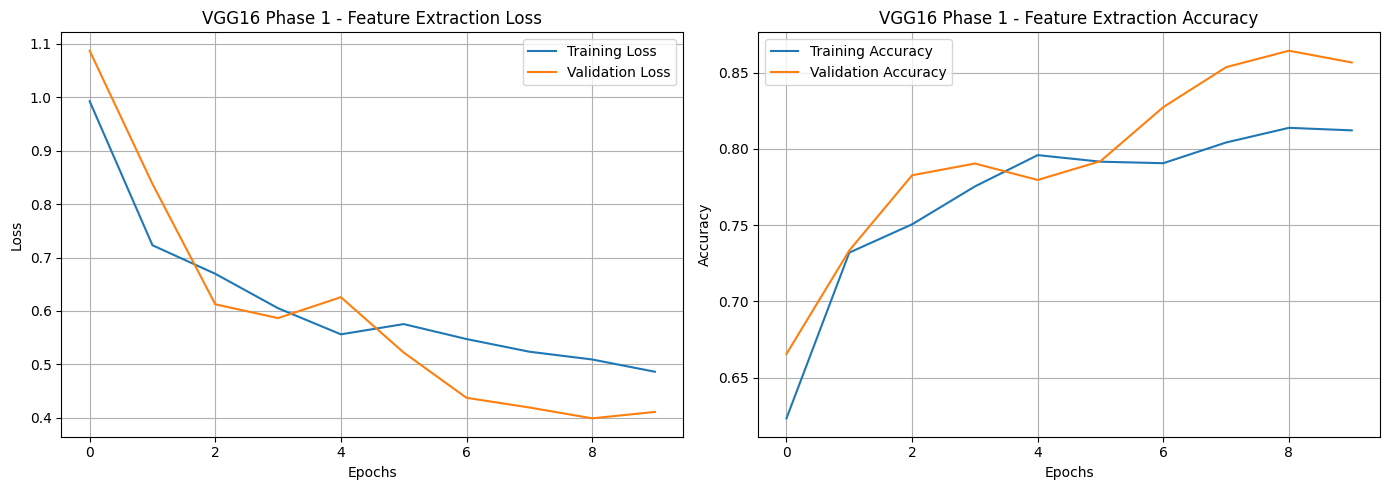

In [31]:
# Plot VGG16 Phase 1 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_vgg_p1.history['loss'], label='Training Loss')
plt.plot(history_vgg_p1.history['val_loss'], label='Validation Loss')
plt.title("VGG16 Phase 1 - Feature Extraction Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_vgg_p1.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg_p1.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG16 Phase 1 - Feature Extraction Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [32]:
# VGG16 Phase 1 Summary
print("=" * 55)
print("VGG16 Phase 1 - Feature Extraction Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_vgg_p1.history['loss'])}")
print(f"Final Training Accuracy   : {history_vgg_p1.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_vgg_p1.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_vgg_p1.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_vgg_p1.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {vgg_p1_training_time:.2f} seconds")
print("=" * 55)

VGG16 Phase 1 - Feature Extraction Summary
Total Epochs Trained      : 10
Final Training Accuracy   : 0.8122
Final Validation Accuracy : 0.8567
Final Training Loss       : 0.4860
Final Validation Loss     : 0.4108
Training Time             : 434.07 seconds


# Phase 2: Fine Tuning - VGG16
- Unfreeze top 4 layers of VGG16 base model.
- VGG16 has fewer layers than MobileNetV2 so we
  unfreeze fewer layers to avoid catastrophic forgetting.
- Train with very low learning rate (0.0001).
- Allow model to adapt pretrained features to flowers.

In [33]:
# Unfreeze top 4 layers of VGG16 for fine tuning
vgg_base.trainable = True

# Freeze all layers except top 4
for layer in vgg_base.layers[:-4]:
  layer.trainable = False

# Count trainable layers
trainable_layers = sum(1 for layer in vgg_base.layers if layer.trainable)
frozen_layers    = sum(1 for layer in vgg_base.layers if not layer.trainable)

print(f"Total Layers in VGG16 : {len(vgg_base.layers)}")
print(f"Frozen Layers         : {frozen_layers}")
print(f"Trainable Layers      : {trainable_layers}")
print(f"\nFine tuning top {trainable_layers} layers!")

Total Layers in VGG16 : 19
Frozen Layers         : 15
Trainable Layers      : 4

Fine tuning top 4 layers!


In [35]:
# Recompile with lower learning rate for fine tuning
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("VGG16 recompiled for Fine Tuning!")
print(f"New Learning Rate : 0.0001")

VGG16 recompiled for Fine Tuning!
New Learning Rate : 0.0001


In [36]:
# Define Callbacks for VGG16 Phase 2
early_stop_vgg_p2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_vgg_p2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-8,
    verbose=1
)

print("VGG16 Phase 2 Callbacks defined!")

VGG16 Phase 2 Callbacks defined!


In [37]:
# Reset generators
train_generator.reset()
val_generator.reset()

print("Generators reset!")
print(f"Training samples   : {train_generator.samples}")
print(f"Validation samples : {val_generator.samples}")

Generators reset!
Training samples   : 3019
Validation samples : 649


In [38]:
# VGG16 Phase 2 Training - Fine Tuning
EPOCHS_VGG_P2 = 10

start_time = time.time()

history_vgg_p2 = vgg_model.fit(
    train_generator,
    epochs=EPOCHS_VGG_P2,
    validation_data=val_generator,
    callbacks=[early_stop_vgg_p2, reduce_lr_vgg_p2],
    verbose=1
)

vgg_p2_training_time = time.time() - start_time
print(f"\nVGG16 Phase 2 Training Time: {vgg_p2_training_time:.2f} seconds")

Epoch 1/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 52s 472ms/step - accuracy: 0.7760 - loss: 0.6403 - val_accuracy: 0.8074 - val_loss: 0.5911 - learning_rate: 1.0000e-04
Epoch 2/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 426ms/step - accuracy: 0.8645 - loss: 0.3955 - val_accuracy: 0.8490 - val_loss: 0.4720 - learning_rate: 1.0000e-04
Epoch 3/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 430ms/step - accuracy: 0.8642 - loss: 0.3702 - val_accuracy: 0.8505 - val_loss: 0.3900 - learning_rate: 1.0000e-04
Epoch 4/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 432ms/step - accuracy: 0.8806 - loss: 0.3089 - val_accuracy: 0.9014 - val_loss: 0.2986 - learning_rate: 1.0000e-04
Epoch 5/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 41s 428ms/step - accuracy: 0.9082 - loss: 0.2428 - val_accuracy: 0.8490 - val_loss: 0.4347 - learning_rate: 1.0000e-04
Epoch 6/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 42s 445ms/step - accuracy: 0.9299 - loss: 0.2232 - val_accuracy: 0.8567 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch 7/10
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accu

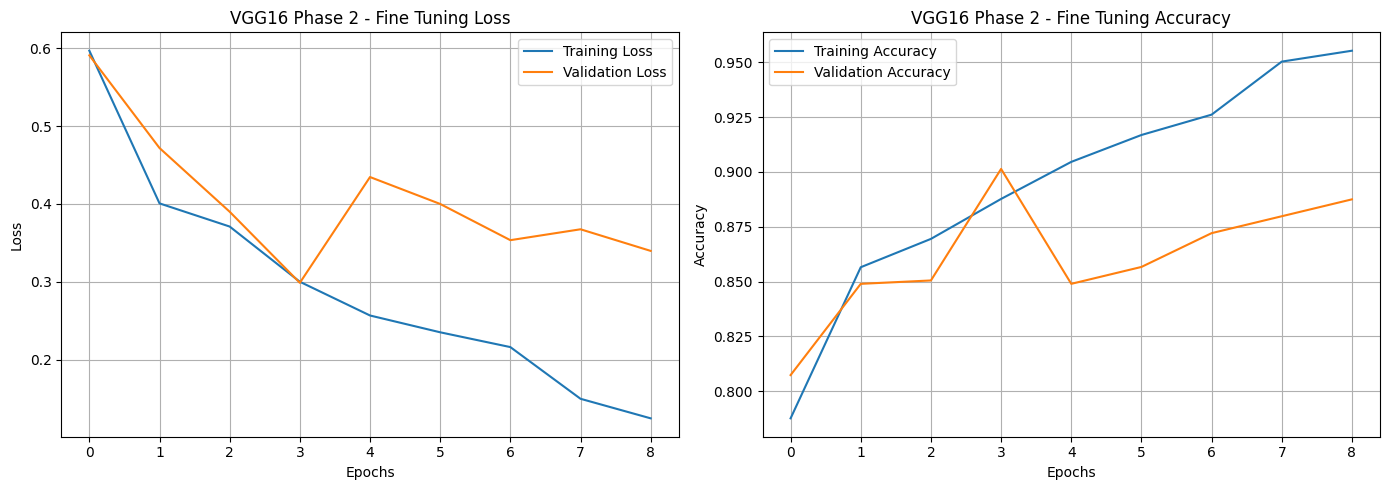

In [39]:
# Plot VGG16 Phase 2 Training Results
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(history_vgg_p2.history['loss'], label='Training Loss')
plt.plot(history_vgg_p2.history['val_loss'], label='Validation Loss')
plt.title("VGG16 Phase 2 - Fine Tuning Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy curve
plt.subplot(1, 2, 2)
plt.plot(history_vgg_p2.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg_p2.history['val_accuracy'], label='Validation Accuracy')
plt.title("VGG16 Phase 2 - Fine Tuning Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

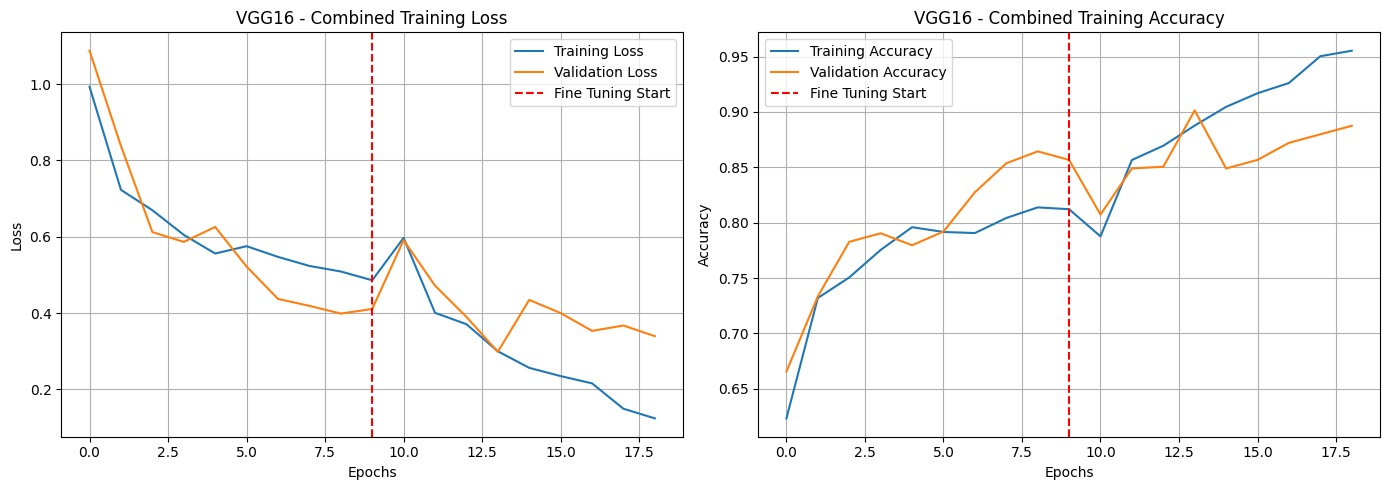

In [40]:
# Plot Combined Phase 1 and Phase 2 for VGG16
acc_vgg      = history_vgg_p1.history['accuracy']     + history_vgg_p2.history['accuracy']
val_acc_vgg  = history_vgg_p1.history['val_accuracy'] + history_vgg_p2.history['val_accuracy']
loss_vgg     = history_vgg_p1.history['loss']         + history_vgg_p2.history['loss']
val_loss_vgg = history_vgg_p1.history['val_loss']     + history_vgg_p2.history['val_loss']

epochs_range = range(len(acc_vgg))

plt.figure(figsize=(14, 5))

# Combined Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, loss_vgg, label='Training Loss')
plt.plot(epochs_range, val_loss_vgg, label='Validation Loss')
plt.axvline(x=len(history_vgg_p1.history['loss']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("VGG16 - Combined Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Combined Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, acc_vgg, label='Training Accuracy')
plt.plot(epochs_range, val_acc_vgg, label='Validation Accuracy')
plt.axvline(x=len(history_vgg_p1.history['accuracy']) - 1,
            color='red', linestyle='--', label='Fine Tuning Start')
plt.title("VGG16 - Combined Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [54]:
# Evaluate VGG16 on validation set
eval_generator.reset()

y_pred_vgg_probs = vgg_model.predict(eval_generator, verbose=1)
y_pred_vgg = np.argmax(y_pred_vgg_probs, axis=1)
y_true = eval_generator.classes

print(f"y_pred shape : {y_pred_vgg.shape}")
print(f"y_true shape : {y_true.shape}")

print("\nClassification Report - VGG16:")
print(classification_report(y_true, y_pred_vgg, target_names=class_names))

21/21 ━━━━━━━━━━━━━━━━━━━━ 5s 202ms/step
y_pred shape : (649,)
y_true shape : (649,)

Classification Report - VGG16:
              precision    recall  f1-score   support

       daisy       0.91      0.93      0.92       115
   dandelion       0.95      0.91      0.93       158
        rose       0.78      0.95      0.86       118
   sunflower       0.94      0.94      0.94       110
       tulip       0.94      0.81      0.87       148

    accuracy                           0.90       649
   macro avg       0.90      0.91      0.90       649
weighted avg       0.91      0.90      0.90       649



<Figure size 800x600 with 0 Axes>

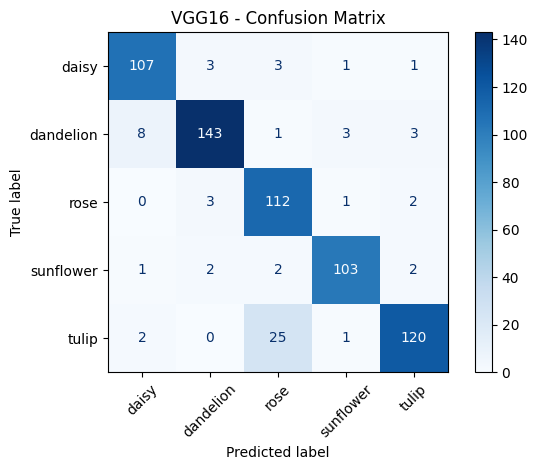

In [55]:
# Confusion Matrix - VGG16
cm_vgg = confusion_matrix(y_true, y_pred_vgg)
disp_vgg = ConfusionMatrixDisplay(
    confusion_matrix=cm_vgg,
    display_labels=class_names
)

plt.figure(figsize=(8, 6))
disp_vgg.plot(cmap='Blues', xticks_rotation=45)
plt.title("VGG16 - Confusion Matrix")
plt.tight_layout()
plt.show()

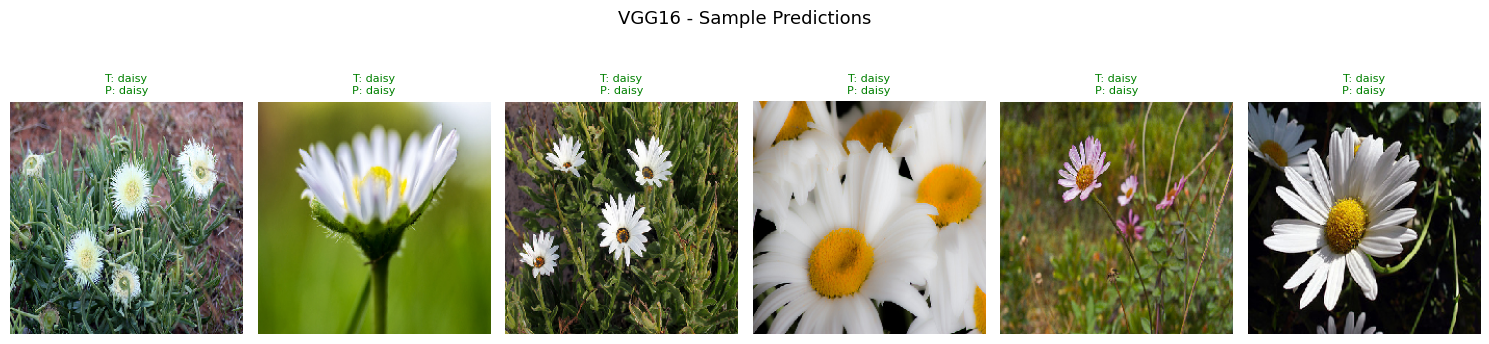

In [56]:
# Inference on sample images
eval_generator.reset()
sample_images, sample_labels = next(eval_generator)

plt.figure(figsize=(15, 4))
for i in range(6):
  img = sample_images[i]
  true_label = class_names[np.argmax(sample_labels[i])]
  pred_label = class_names[np.argmax(
      vgg_model.predict(img[np.newaxis, ...], verbose=0))]

  plt.subplot(1, 6, i + 1)
  plt.imshow(img)
  plt.title(f"T: {true_label}\nP: {pred_label}", fontsize=8,
            color='green' if true_label == pred_label else 'red')
  plt.axis('off')

plt.suptitle("VGG16 - Sample Predictions", fontsize=13)
plt.tight_layout()
plt.show()

In [79]:
# VGG16 Phase 2 Summary
print("=" * 55)
print("VGG16 Phase 2 - Fine Tuning Summary")
print("=" * 55)
print(f"Total Epochs Trained      : {len(history_vgg_p2.history['loss'])}")
print(f"Final Training Accuracy   : {history_vgg_p2.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy : {history_vgg_p2.history['val_accuracy'][-1]:.4f}")
print(f"Final Training Loss       : {history_vgg_p2.history['loss'][-1]:.4f}")
print(f"Final Validation Loss     : {history_vgg_p2.history['val_loss'][-1]:.4f}")
print(f"Training Time             : {vgg_p2_training_time:.2f} seconds")
print("=" * 55)

VGG16 Phase 2 - Fine Tuning Summary
Total Epochs Trained      : 9
Final Training Accuracy   : 0.9553
Final Validation Accuracy : 0.8875
Final Training Loss       : 0.1244
Final Validation Loss     : 0.3397
Training Time             : 386.21 seconds


# Observations - VGG16 Transfer Learning

## Phase 2 - Fine Tuning Analysis:

### Training Progress:
* Early stopping triggered at epoch 9 and restored
  weights from best epoch 4 (val_accuracy = 0.9014)
* This shows the model started overfitting after epoch 4
* ReduceLROnPlateau reduced learning rate at epoch 7
  from 0.0001 to 0.00005 to help fine tuning
* Training accuracy reached 95.26% while validation
  accuracy was 88.75% at epoch 9 showing overfitting

### Loss Analysis:
* Training loss decreased steadily from 0.64 to 0.13
* Validation loss decreased initially then increased
  after epoch 4 confirming overfitting in later epochs
* Best validation loss was 0.2986 at epoch 4

### Accuracy Analysis:
* Training accuracy increased rapidly from 77.60% to 95.53%
* Validation accuracy peaked at 90.14% at epoch 4
* After epoch 4 validation accuracy fluctuated showing
  the model was memorizing training data
* Early stopping correctly restored best weights 

## Classification Report Analysis - VGG16:

### Overall Performance:
* VGG16 achieved 90% overall accuracy
* Macro average F1 score : 0.90
* Weighted average F1    : 0.90

### Class wise Analysis:
* Best performing classes:
  → sunflower : F1 = 0.94 (best class!)
    Precision = 0.94, Recall = 0.94
    Very balanced and reliable performance
  → dandelion : F1 = 0.93
    Consistent with MobileNetV2 performance
  → daisy     : F1 = 0.92
    High recall of 0.93 shows model finds most daisies

* Good performing classes:
  → rose      : F1 = 0.86
    Recall = 0.95 (very high!)
    But precision = 0.78 (lower)
    Model over predicts rose class slightly
  → tulip     : F1 = 0.87
    Precision = 0.94 but Recall = 0.81
    Model is conservative in predicting tulip

## VGG16 vs MobileNetV2 Comparison:

### Accuracy:
* MobileNetV2 : 92.76% Higher accuracy
* VGG16       : 90.14%
* Difference  : 2.62% in favor of MobileNetV2

### Class wise F1 Comparison:
* daisy     : MobileNetV2 0.91 vs VGG16 0.92  → VGG16 slightly better
* dandelion : MobileNetV2 0.93 vs VGG16 0.93  → Same
* rose      : MobileNetV2 0.92 vs VGG16 0.86  → MobileNetV2 better
* sunflower : MobileNetV2 0.89 vs VGG16 0.94  → VGG16 better
* tulip     : MobileNetV2 0.92 vs VGG16 0.87  → MobileNetV2 better

### Training Time:
* MobileNetV2 : 841.76 seconds
* VGG16       : 820.28 seconds
* VGG16 was slightly faster despite being heavier
  because early stopping triggered at epoch 9

### Overfitting:
* MobileNetV2 : Training 97% vs Validation 92% → Gap 5%
* VGG16       : Training 95% vs Validation 90% → Gap 5%
* Both models show similar levels of mild overfitting

## Why MobileNetV2 Outperformed VGG16:
* MobileNetV2 uses depthwise separable convolutions
  which are more efficient at extracting features
  from small datasets like flowers.
* VGG16 has 138 million parameters compared to only
  3.4 million in MobileNetV2 making it harder to
  fine tune effectively on small datasets.
* MobileNetV2 architecture is specifically designed
  for efficient feature extraction with fewer parameters
  which is ideal for our 3019 image training set.
* VGG16 started overfitting earlier (epoch 4) while
  MobileNetV2 maintained stable performance longer.

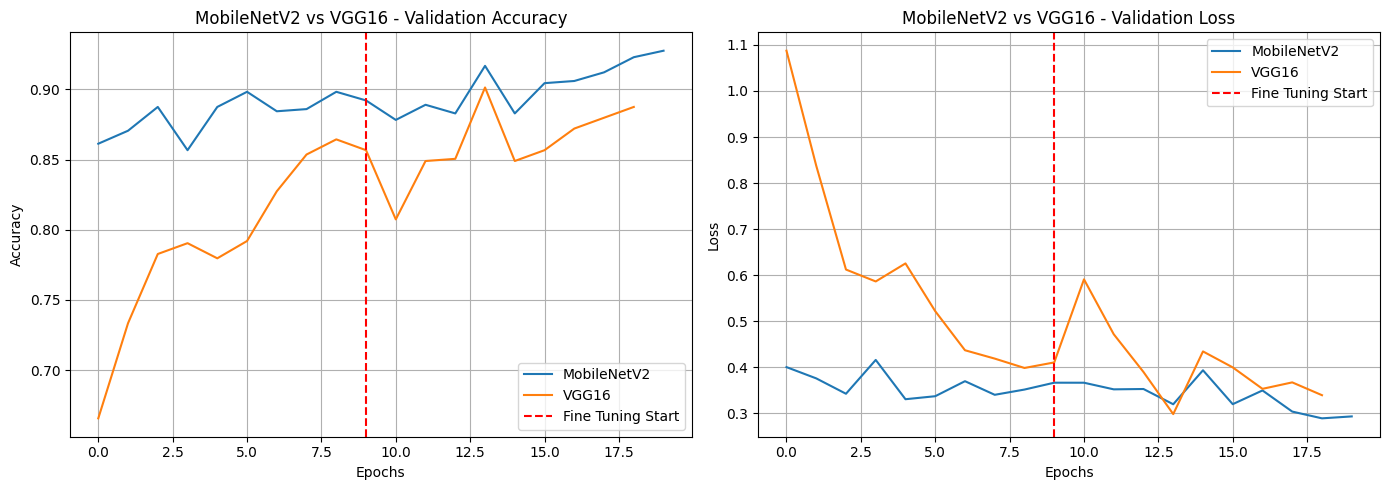

In [80]:
# MobileNetV2 vs VGG16 Comparison Plot
plt.figure(figsize=(14, 5))

# Accuracy comparison
plt.subplot(1, 2, 1)
plt.plot(history_p1.history['val_accuracy'] +
         history_p2.history['val_accuracy'],
         label='MobileNetV2')
plt.plot(history_vgg_p1.history['val_accuracy'] +
         history_vgg_p2.history['val_accuracy'],
         label='VGG16')
plt.axvline(x=9, color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 vs VGG16 - Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss comparison
plt.subplot(1, 2, 2)
plt.plot(history_p1.history['val_loss'] +
         history_p2.history['val_loss'],
         label='MobileNetV2')
plt.plot(history_vgg_p1.history['val_loss'] +
         history_vgg_p2.history['val_loss'],
         label='VGG16')
plt.axvline(x=9, color='red', linestyle='--', label='Fine Tuning Start')
plt.title("MobileNetV2 vs VGG16 - Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [108]:
# Final Complete Summary - All Models
print("=" * 75)
print(f"{'Model':<28} {'Val Accuracy':>12} {'Val Loss':>10} {'Time(s)':>12}")
print("=" * 75)
print(f"{'Baseline CNN':<28} "
      f"{max(baseline_history.history['val_accuracy']):>12.4f} "
      f"{min(baseline_history.history['val_loss']):>10.4f} "
      f"{baseline_training_time:>12.2f}")
print(f"{'Deeper CNN (Adam)':<28} "
      f"{max(deeper_history.history['val_accuracy']):>12.4f} "
      f"{min(deeper_history.history['val_loss']):>10.4f} "
      f"{deeper_training_time:>12.2f}")
print(f"{'Deeper CNN (SGD)':<28} "
      f"{max(history_sgd.history['val_accuracy']):>12.4f} "
      f"{min(history_sgd.history['val_loss']):>10.4f} "
      f"{sgd_training_time:>12.2f}")
print(f"{'Deeper CNN (No Dropout)':<28} "
      f"{max(history_no_dropout.history['val_accuracy']):>12.4f} "
      f"{min(history_no_dropout.history['val_loss']):>10.4f} "
      f"{no_dropout_training_time:>12.2f}")
print(f"{'MobileNetV2 (Transfer)':<28} "
      f"{max(max(history_p1.history['val_accuracy']), max(history_p2.history['val_accuracy'])):>12.4f} "
      f"{min(min(history_p1.history['val_loss']), min(history_p2.history['val_loss'])):>10.4f} "
      f"{p1_training_time + p2_training_time:>12.2f}")
print(f"{'VGG16 (Transfer)':<28} "
      f"{max(max(history_vgg_p1.history['val_accuracy']), max(history_vgg_p2.history['val_accuracy'])):>12.4f} "
      f"{min(min(history_vgg_p1.history['val_loss']), min(history_vgg_p2.history['val_loss'])):>10.4f} "
      f"{vgg_p1_training_time + vgg_p2_training_time:>12.2f}")
print("=" * 75)

Model                        Val Accuracy   Val Loss      Time(s)
Baseline CNN                       0.7797     0.6128       759.99
Deeper CNN (Adam)                  0.7304     0.7112       877.27
Deeper CNN (SGD)                   0.6086     0.9754       874.03
Deeper CNN (No Dropout)            0.8136     0.5354       890.74
MobileNetV2 (Transfer)             0.9276     0.2894       841.76
VGG16 (Transfer)                   0.9014     0.2986       820.28


# Final Summary - All Models Complete Comparison

## Accuracy Ranking:
* 1st : MobileNetV2 Transfer  → 92.76% Best!
* 2nd : VGG16 Transfer        → 90.14%
* 3rd : Deeper CNN No Dropout → 81.36%
* 4th : Baseline CNN          → 77.97%
* 5th : Deeper CNN Adam       → 73.04%
* 6th : Deeper CNN SGD        → 60.86% (worst)

## Key Findings from Summary Table:

1. Transfer Learning dominates:
   * MobileNetV2 (92.76%) and VGG16 (90.14%) are the
     top two models by a significant margin.
   * Both transfer learning models outperform all
     scratch trained models by at least 8.78%.
   * This confirms that pretrained ImageNet features
     are highly effective for flower classification.

2. Surprising finding - No Dropout model (81.36%):
   * Outperformed both Baseline CNN (77.97%) and
     all Deeper CNN with Dropout variants.
   * Third best model overall!
   * Confirms that BatchNormalization alone provides
     sufficient regularization for this dataset.

3. Baseline CNN beats Deeper models:
   * Baseline (77.97%) outperformed Deeper Adam (73.04%)
     and Deeper SGD (60.86%).
   * Simpler models work better on small datasets.

4. SGD performed worst (60.86%):
   * Fixed learning rate struggled to converge
     on this complex flower classification task.
   * Adam adaptive learning rate is clearly superior.

5. Training Time Analysis:
   * Deeper models took longest (874-890 seconds)
     despite achieving lower accuracy than baseline.
   * Transfer learning models achieved highest accuracy
     in similar or less time than scratch models.
   * MobileNetV2 is the most efficient model:
     highest accuracy (92.76%) in 841 seconds.

## Conclusion:
* MobileNetV2 with transfer learning is the best model
  for flower classification achieving 92.76% accuracy.
* Transfer learning is strongly recommended over training
  from scratch especially for small datasets.
* For resource constrained deployments the baseline CNN
  offers a good balance of accuracy (77.97%) and speed.